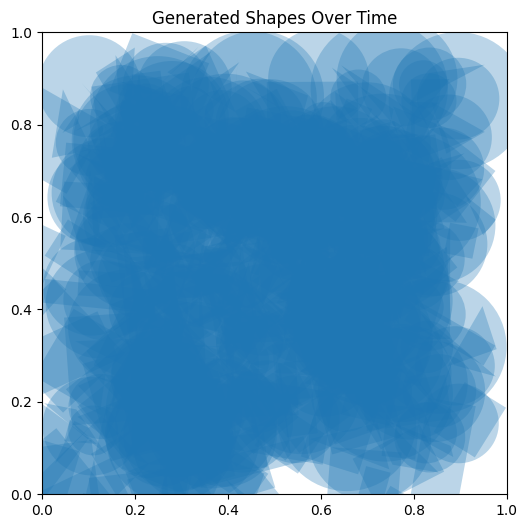

In [ ]:
## GAN-GA that generates variations in shape over time.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon

# -----------------------------
# Generator: produces a shape
# -----------------------------
def generator(z, t):
    rng = np.random.default_rng(seed=int(z[0] * 1e6) + t)

    shape_type = rng.choice(["circle", "rectangle", "triangle"])
    x, y = rng.uniform(0.1, 0.9), rng.uniform(0.1, 0.9)
    theta = rng.uniform(0, 2 * np.pi)

    if shape_type == "circle":
        r = rng.uniform(0.05, 0.15)
        geom = {
            "type": "circle",
            "center": (x, y),
            "radius": r,
            "orientation": theta,
            "time_origin": t
        }

    elif shape_type == "rectangle":
        w, h = rng.uniform(0.05, 0.25), rng.uniform(0.05, 0.25)
        geom = {
            "type": "rectangle",
            "center": (x, y),
            "width": w,
            "height": h,
            "orientation": theta,
            "time_origin": t
        }

    else:  # triangle
        offsets = rng.uniform(-0.1, 0.1, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        geom = {
            "type": "triangle",
            "vertices": vertices,
            "orientation": theta,
            "time_origin": t
        }

    return geom


# -----------------------------
# Run simulation over time
# -----------------------------
num_shapes = 100
latent_dim = 4

shapes = []
latent_vectors = np.random.rand(num_shapes, latent_dim)

for t in range(5):  # 5 time steps
    for i in range(num_shapes):
        shape = generator(latent_vectors[i], t)
        shape["id"] = f"{t}-{i}"
        shapes.append(shape)


# -----------------------------
# Convert to table
# -----------------------------
rows = []
for s in shapes:
    if s["type"] == "circle":
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["center"], f"r={s['radius']:.3f}", s["orientation"]
        ])
    elif s["type"] == "rectangle":
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["center"], f"{s['width']:.3f}×{s['height']:.3f}", s["orientation"]
        ])
    else:  # triangle
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["vertices"], "3 vertices", s["orientation"]
        ])

df = pd.DataFrame(rows, columns=[
    "ID", "Time", "Type", "Position/Vertices", "Size", "Orientation"
])

# Each shape is located along its centroid value in bivariate space.


# -----------------------------
# Plot shapes
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Generated Shapes Over Time")

for s in shapes:
    if s["type"] == "circle":
        circ = Circle(s["center"], s["radius"], alpha=0.3)
        ax.add_patch(circ)

    elif s["type"] == "rectangle":
        x, y = s["center"]
        w, h = s["width"], s["height"]
        rect = Rectangle((x - w/2, y - h/2), w, h, angle=np.degrees(s["orientation"]), alpha=0.3)
        ax.add_patch(rect)

    else:  # triangle
        tri = Polygon(s["vertices"], alpha=0.3)
        ax.add_patch(tri)

plt.show()

<Figure size 1000x600 with 0 Axes>

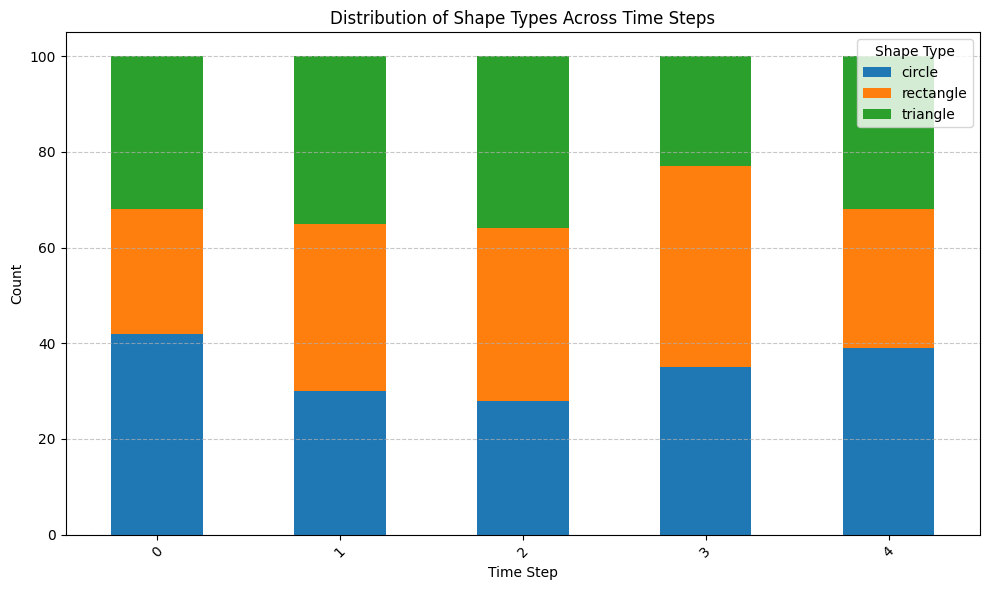

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Time and Type to get the counts of each shape type at each time step
shape_time_distribution = df.groupby(['Time', 'Type']).size().unstack(fill_value=0)

# Create a stacked bar plot
fig = plt.figure(figsize=(10, 6))
shape_time_distribution.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribution of Shape Types Across Time Steps')
plt.xlabel('Time Step')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Shape Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print('Distribution of Shape Types:')
display(df['Type'].value_counts())

Distribution of Shape Types:


,count
Type,
circle,174
rectangle,168
triangle,158


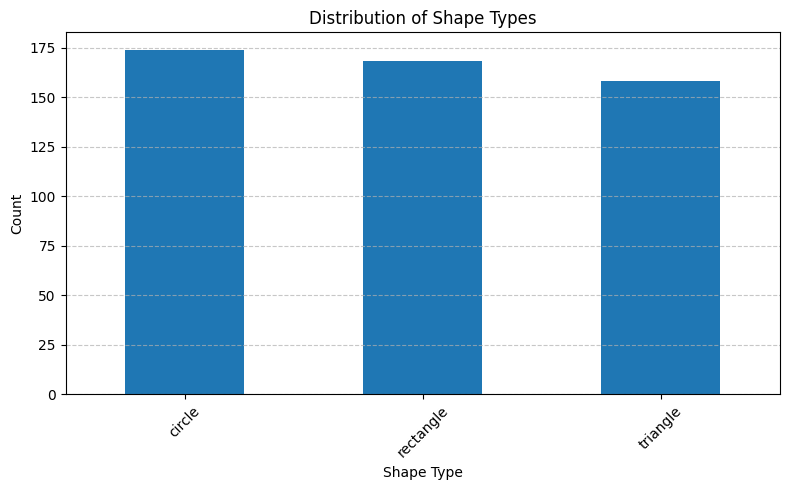

In [ ]:
import matplotlib.pyplot as plt

# Create a bar chart of the shape type distribution
plt.figure(figsize=(8, 5))
df['Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Shape Types')
plt.xlabel('Shape Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print('DataFrame Info:')
df.info()
print('\nFirst 5 rows of the DataFrame:')
display(df.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 500 non-null    object 
 1   Time               500 non-null    int64  
 2   Type               500 non-null    object 
 3   Position/Vertices  500 non-null    object 
 4   Size               500 non-null    object 
 5   Orientation        500 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 23.6+ KB

First 5 rows of the DataFrame:


,ID,Time,Type,Position/Vertices,Size,Orientation
0,0-0,0,circle,"(0.7387251489524308, 0.21631501113344634)",r=0.146,1.612619
1,0-1,0,circle,"(0.793263657224156, 0.24109995643689353)",r=0.123,1.098621
2,0-2,0,circle,"(0.287594099971741, 0.47544729287713816)",r=0.067,4.043220
3,0-3,0,triangle,"[(0.9093163817671213, 0.7380640934051423), (0....",3 vertices,4.910517
4,0-4,0,triangle,"[(0.22478911736882035, 0.8441040689047703), (0...",3 vertices,3.199219



Evolved Shapes (GAN + GA):

            ID  Time       Type  Position/Vertices         Size  Orientation
0   gen0_rank0     0  rectangle  (0.0, 0.40351474)  0.260×0.020     2.749317
1   gen0_rank1     0     circle  (0.0, 0.37852108)      r=0.281     4.372571
2   gen0_rank2     0  rectangle  (0.0, 0.37792075)  0.154×0.020     3.908457
3   gen0_rank3     0  rectangle  (0.0, 0.37249535)  0.146×0.020     2.716354
4   gen0_rank4     0     circle   (0.0, 0.3300562)      r=0.300     3.584328
5   gen1_rank0     1     circle  (0.0, 0.35601056)      r=0.291     4.365523
6   gen1_rank1     1     circle  (0.0, 0.35877424)      r=0.231     4.104275
7   gen1_rank2     1  rectangle   (0.0, 0.3435591)  0.217×0.020     2.452418
8   gen1_rank3     1  rectangle  (0.0, 0.28692648)  0.212×0.020     4.666692
9   gen1_rank4     1  rectangle  (0.0, 0.31687817)  0.234×0.020     2.569864
10  gen2_rank0     2  rectangle  (0.0, 0.30656755)  0.300×0.020     2.786539
11  gen2_rank1     2     circle  (0.0, 0.282387

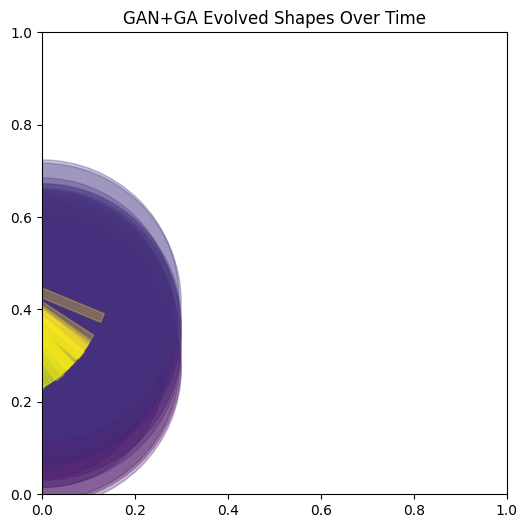

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon

import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Shape utilities
# -----------------------------

SHAPE_TYPES = ["circle", "rectangle", "triangle"]

def random_shape():
    rng = np.random.default_rng()
    shape_type = rng.choice(SHAPE_TYPES)
    x, y = rng.uniform(0.1, 0.9), rng.uniform(0.1, 0.9)
    theta = rng.uniform(0, 2 * np.pi)

    if shape_type == "circle":
        r = rng.uniform(0.05, 0.15)
        return {
            "type": "circle",
            "center": (x, y),
            "radius": r,
            "width": 0.0,
            "height": 0.0,
            "orientation": theta,
        }
    elif shape_type == "rectangle":
        w, h = rng.uniform(0.05, 0.25), rng.uniform(0.05, 0.25)
        return {
            "type": "rectangle",
            "center": (x, y),
            "radius": 0.0,
            "width": w,
            "height": h,
            "orientation": theta,
        }
    else:  # triangle
        offsets = rng.uniform(-0.1, 0.1, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {
            "type": "triangle",
            "center": (x, y),
            "radius": 0.0,
            "width": 0.0,
            "height": 0.0,
            "vertices": vertices,
            "orientation": theta,
        }

def encode_shape(shape):
    # vector: [type_one_hot(3), x, y, size1, size2, orientation_norm]
    t = np.zeros(3, dtype=np.float32)
    idx = SHAPE_TYPES.index(shape["type"])
    t[idx] = 1.0
    x, y = shape["center"]
    if shape["type"] == "circle":
        s1, s2 = shape["radius"], 0.0
    elif shape["type"] == "rectangle":
        s1, s2 = shape["width"], shape["height"]
    else:
        # approximate size by bounding box of vertices
        xs = [v[0] for v in shape["vertices"]]
        ys = [v[1] for v in shape["vertices"]]
        s1 = (max(xs) - min(xs))
        s2 = (max(ys) - min(ys))
    theta = shape["orientation"] / (2 * np.pi)  # normalize
    return np.array([*t, x, y, s1, s2, theta], dtype=np.float32)

def decode_vector(vec):
    vec = vec.detach().cpu().numpy()
    t_logits = vec[:3]
    t_idx = int(np.argmax(t_logits))
    shape_type = SHAPE_TYPES[t_idx]
    x = np.clip(vec[3], 0.0, 1.0)
    y = np.clip(vec[4], 0.0, 1.0)
    s1 = np.clip(vec[5], 0.0, 0.3)
    s2 = np.clip(vec[6], 0.0, 0.3)
    theta = (np.clip(vec[7], 0.0, 1.0)) * 2 * np.pi

    if shape_type == "circle":
        return {
            "type": "circle",
            "center": (x, y),
            "radius": max(s1, 0.02),
            "orientation": theta,
        }
    elif shape_type == "rectangle":
        return {
            "type": "rectangle",
            "center": (x, y),
            "width": max(s1, 0.02),
            "height": max(s2, 0.02),
            "orientation": theta,
        }
    else:
        # simple triangle around center
        rng = np.random.default_rng()
        offsets = rng.uniform(-0.1, 0.1, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {
            "type": "triangle",
            "vertices": vertices,
            "orientation": theta,
        }

# -----------------------------
# GAN: Generator & Discriminator
# -----------------------------

latent_dim = 8
data_dim = 8  # encoded shape vector length

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, out_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cpu")

G = Generator(latent_dim, data_dim).to(device)
D = Discriminator(data_dim).to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=2e-3)
opt_D = optim.Adam(D.parameters(), lr=2e-3)

# -----------------------------
# Build synthetic "real" dataset
# -----------------------------

num_real = 512
real_shapes = [random_shape() for _ in range(num_real)]
real_vecs = np.stack([encode_shape(s) for s in real_shapes], axis=0)
real_tensor = torch.tensor(real_vecs, device=device)

# -----------------------------
# Train GAN briefly
# -----------------------------

batch_size = 400
epochs = 5

for epoch in range(epochs):
    perm = torch.randperm(num_real)
    for i in range(0, num_real, batch_size):
        idx = perm[i:i+batch_size]
        real_batch = real_tensor[idx]

        # Train D
        z = torch.randn(real_batch.size(0), latent_dim, device=device)
        fake_batch = G(z).detach()

        D_real = D(real_batch)
        D_fake = D(fake_batch)

        loss_D = criterion(D_real, torch.ones_like(D_real)) + \
                 criterion(D_fake, torch.zeros_like(D_fake))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train G
        z = torch.randn(real_batch.size(0), latent_dim, device=device)
        fake_batch = G(z)
        D_fake = D(fake_batch)
        loss_G = criterion(D_fake, torch.ones_like(D_fake))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

# -----------------------------
# Genetic Algorithm on latent space
# -----------------------------

def fitness(z_batch):
    with torch.no_grad():
        shapes_vec = G(z_batch)
        scores = D(shapes_vec).squeeze()  # realism score
        # Encourage center near (0.5,0.5)
        xs = torch.clamp(shapes_vec[:, 3], 0.0, 1.0)
        ys = torch.clamp(shapes_vec[:, 4], 0.0, 1.0)
        center_penalty = torch.abs(xs - 0.5) + torch.abs(ys - 0.5)
        fit = scores - 0.5 * center_penalty
    return fit

pop_size = 400
generations = 100

population = torch.randn(pop_size, latent_dim, device=device)

history_shapes = []

for gen in range(generations):
    # Evaluate fitness
    fits = fitness(population)
    # Select top half
    topk = torch.topk(fits, k=pop_size // 2)
    parents = population[topk.indices]

    # Record best shapes this generation
    best_z = parents[0:5]  # top 5
    with torch.no_grad():
        best_vecs = G(best_z)
    for j, v in enumerate(best_vecs):
        shape = decode_vector(v)
        shape["time_origin"] = gen
        shape["id"] = f"gen{gen}_rank{j}"
        history_shapes.append(shape)

    # Crossover + mutation to refill population
    children = []
    rng = np.random.default_rng()
    while len(children) < pop_size:
        p1, p2 = parents[rng.integers(0, parents.size(0), 2)]
        alpha = torch.rand(1, device=device)
        child = alpha * p1 + (1 - alpha) * p2
        # mutation
        child += 0.1 * torch.randn_like(child)
        children.append(child.unsqueeze(0))
    population = torch.cat(children, dim=0)[:pop_size]

# -----------------------------
# Build table of GA-generated shapes
# -----------------------------

rows = []
for s in history_shapes:
    if s["type"] == "circle":
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["center"], f"r={s['radius']:.3f}", s["orientation"],
        ])
    elif s["type"] == "rectangle":
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["center"], f"{s['width']:.3f}×{s['height']:.3f}", s["orientation"],
        ])
    else:
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["vertices"], "3 vertices", s["orientation"],
        ])

df = pd.DataFrame(rows, columns=[
    "ID", "Time", "Type", "Position/Vertices", "Size", "Orientation"
])

print("\nEvolved Shapes (GAN + GA):\n")
print(df.head(30))  # print first 30 rows

# -----------------------------
# Plot shapes by time of origin
# -----------------------------

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("GAN+GA Evolved Shapes Over Time")

colors = plt.cm.viridis(np.linspace(0, 1, generations))

for s in history_shapes:
    t = s["time_origin"]
    color = colors[t]
    if s["type"] == "circle":
        circ = Circle(s["center"], s["radius"], alpha=0.3, color=color)
        ax.add_patch(circ)
    elif s["type"] == "rectangle":
        x, y = s["center"]
        w, h = s["width"], s["height"]
        rect = Rectangle(
            (x - w/2, y - h/2),
            w, h,
            angle=np.degrees(s["orientation"]),
            alpha=0.3,
            color=color,
        )
        ax.add_patch(rect)
    else:
        tri = Polygon(s["vertices"], alpha=0.3, color=color)
        ax.add_patch(tri)

plt.show()


Inventory of generated shapes (initial):

ID  Time      Type          Position/Vertices        Size  Fitness
t0     0 rectangle                 (0.0, 1.0) 0.199×0.300 0.536094
t1     1 rectangle                 (0.0, 1.0) 0.150×0.300 0.239178
t2     2 rectangle   (0.0, 0.342701256275177) 0.020×0.300 1.099092
t3     3 rectangle  (0.0, 0.5559365749359131) 0.020×0.300 1.332962
t4     4 rectangle                 (0.0, 0.0) 0.238×0.300 0.385230
t5     5 rectangle                 (0.0, 0.0) 0.020×0.300 0.755933
t6     6 rectangle                 (0.0, 0.0) 0.020×0.300 0.785044
t7     7 rectangle (0.0, 0.16265767812728882) 0.142×0.300 0.730089

Column Information (initial):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 8 non-null      object 
 1   Time               8 non-null      int64  
 2   Type               8 non-

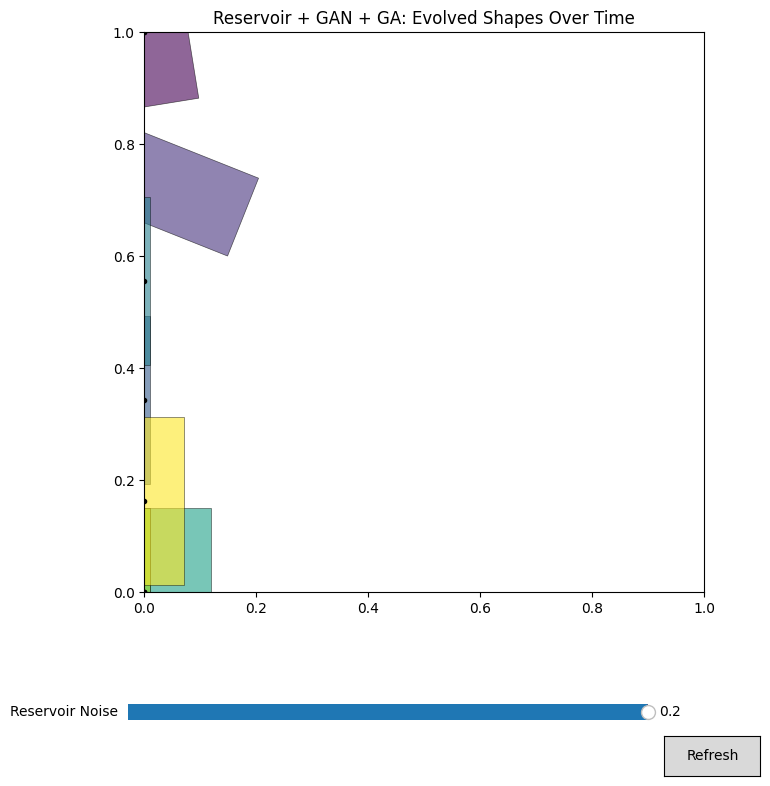

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
from matplotlib.widgets import Slider, Button
import torch
import torch.nn as nn
import torch.optim as optim
import time

# -----------------------------
# Deterministic seeds
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# Echo State Network (ESN)
# -----------------------------
class ESN:
    def __init__(self, in_dim, res_size=200, spectral_radius=0.9, input_scaling=0.5, leak_rate=1.0, seed=SEED):
        rng = np.random.default_rng(seed)
        self.in_dim = in_dim
        self.res_size = res_size
        self.W_in = (rng.standard_normal((res_size, in_dim)) * input_scaling).astype(np.float32)
        W = rng.standard_normal((res_size, res_size)).astype(np.float32)
        # spectral radius scaling
        eigs = np.linalg.eigvals(W)
        radius = np.max(np.abs(eigs))
        if radius == 0:
            radius = 1.0
        self.W = (W * (spectral_radius / radius)).astype(np.float32)
        self.leak_rate = leak_rate
        self.state = np.zeros(res_size, dtype=np.float32)

    def step(self, u, noise_scale=0.0):
        # u: input vector (in_dim,)
        pre = self.W @ self.state + self.W_in @ u
        noise = np.random.normal(scale=noise_scale, size=self.res_size).astype(np.float32)
        new_state = (1 - self.leak_rate) * self.state + self.leak_rate * np.tanh(pre + noise)
        self.state = new_state
        return self.state.copy()

    def reset(self):
        self.state[:] = 0.0

# -----------------------------
# Procedural shape utilities
# -----------------------------
SHAPE_TYPES = ["circle", "rectangle", "triangle"]

def random_shape():
    rng = np.random.default_rng()
    shape_type = rng.choice(SHAPE_TYPES)
    x, y = rng.uniform(0.1, 0.9), rng.uniform(0.1, 0.9)
    theta = rng.uniform(0, 2 * np.pi)
    if shape_type == "circle":
        r = rng.uniform(0.05, 0.15)
        return {"type": "circle", "center": (x, y), "radius": r, "orientation": theta}
    elif shape_type == "rectangle":
        w, h = rng.uniform(0.05, 0.25), rng.uniform(0.05, 0.25)
        return {"type": "rectangle", "center": (x, y), "width": w, "height": h, "orientation": theta}
    else:
        offsets = rng.uniform(-0.08, 0.08, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {"type": "triangle", "vertices": vertices, "orientation": theta}

def encode_shape(shape):
    # vector: [type_one_hot(3), x, y, size1, size2, orientation_norm] -> length 8
    t = np.zeros(3, dtype=np.float32)
    idx = SHAPE_TYPES.index(shape["type"])
    t[idx] = 1.0
    if shape["type"] == "circle":
        x, y = shape["center"]
        s1, s2 = shape["radius"], 0.0
    elif shape["type"] == "rectangle":
        x, y = shape["center"]
        s1, s2 = shape["width"], shape["height"]
    else:
        xs = [v[0] for v in shape["vertices"]]
        ys = [v[1] for v in shape["vertices"]]
        x, y = np.mean(xs), np.mean(ys)
        s1 = (max(xs) - min(xs))
        s2 = (max(ys) - min(ys))
    theta = shape["orientation"] / (2 * np.pi)
    return np.array([*t, x, y, s1, s2, theta], dtype=np.float32)

def decode_vector(vec):
    # vec: numpy array length 8
    t_logits = vec[:3]
    t_idx = int(np.argmax(t_logits))
    shape_type = SHAPE_TYPES[t_idx]
    x = float(np.clip(vec[3], 0.0, 1.0))
    y = float(np.clip(vec[4], 0.0, 1.0))
    s1 = float(np.clip(vec[5], 0.0, 0.3))
    s2 = float(np.clip(vec[6], 0.0, 0.3))
    theta = float(np.clip(vec[7], 0.0, 1.0)) * 2 * np.pi
    if shape_type == "circle":
        return {"type": "circle", "center": (x, y), "radius": max(s1, 0.02), "orientation": theta}
    elif shape_type == "rectangle":
        return {"type": "rectangle", "center": (x, y), "width": max(s1, 0.02), "height": max(s2, 0.02), "orientation": theta}
    else:
        rng = np.random.default_rng(int((x + y) * 1e6) % 2**31)
        offsets = rng.uniform(-0.08, 0.08, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {"type": "triangle", "vertices": vertices, "orientation": theta}

# -----------------------------
# Small GAN (PyTorch MLP)
# -----------------------------
latent_dim = 8
context_dim = 32  # reservoir context projection size
gen_input_dim = latent_dim + context_dim
data_dim = 8  # shape descriptor length

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cpu")
G = Generator(gen_input_dim, data_dim).to(device)
D = Discriminator(data_dim).to(device)
opt_G = optim.Adam(G.parameters(), lr=1e-3)
opt_D = optim.Adam(D.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# -----------------------------
# Build synthetic "real" dataset
# -----------------------------
num_real = 512
real_shapes = [random_shape() for _ in range(num_real)]
real_vecs = np.stack([encode_shape(s) for s in real_shapes], axis=0)
real_tensor = torch.tensor(real_vecs, dtype=torch.float32, device=device)

# For conditioning, create random context vectors for training
train_contexts = torch.randn(num_real, context_dim, device=device) * 0.5

# -----------------------------
# Train GAN briefly (small epochs)
# -----------------------------
def train_gan(epochs=12, batch_size=64):
    n = real_tensor.size(0)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            real_batch = real_tensor[idx]
            ctx = train_contexts[idx]

            # Train D
            z = torch.randn(real_batch.size(0), latent_dim, device=device)
            gen_in = torch.cat([z, ctx], dim=1)
            fake_batch = G(gen_in).detach()

            D_real = D(real_batch)
            D_fake = D(fake_batch)

            loss_D = criterion(D_real, torch.ones_like(D_real)) + \
                     criterion(D_fake, torch.zeros_like(D_fake))

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Train G
            z = torch.randn(real_batch.size(0), latent_dim, device=device)
            gen_in = torch.cat([z, ctx], dim=1)
            fake_batch = G(gen_in)
            D_fake = D(fake_batch)
            loss_G = criterion(D_fake, torch.ones_like(D_fake))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

# Train once
train_gan(epochs=12)

# -----------------------------
# Reservoir -> context projection
# -----------------------------
proj_W = np.random.RandomState(SEED).normal(scale=0.5, size=(context_dim, 200)).astype(np.float32)

def reservoir_to_context(res_state):
    # res_state: numpy array length res_size (200)
    ctx = proj_W @ res_state  # (context_dim,)
    return ctx.astype(np.float32)

# -----------------------------
# Genetic Algorithm utilities
# -----------------------------
def fitness_scores(pop_z, ctx_vec, prev_z=None):
    """
    pop_z: torch tensor (pop_size, latent_dim)
    ctx_vec: numpy array (context_dim,)
    prev_z: torch tensor (latent_dim,) or None
    Returns: fitness tensor (pop_size,)
    """
    with torch.no_grad():
        ctx = torch.tensor(ctx_vec, dtype=torch.float32, device=device).unsqueeze(0).repeat(pop_z.size(0), 1)
        gen_in = torch.cat([pop_z, ctx], dim=1)
        out = G(gen_in)  # (pop, data_dim)
        d_scores = D(out).squeeze()  # realism in [0,1]

        # geometric desirability: prefer center near (0.5,0.5) and moderate size
        xs = torch.clamp(out[:, 3], 0.0, 1.0)
        ys = torch.clamp(out[:, 4], 0.0, 1.0)
        center_score = 1.0 - (torch.abs(xs - 0.5) + torch.abs(ys - 0.5))  # range approx [-0.5,1]
        s1 = torch.clamp(out[:, 5], 0.0, 0.3)
        s2 = torch.clamp(out[:, 6], 0.0, 0.3)
        preferred_size = 0.12
        size_score = 1.0 - torch.abs((s1 + s2) / 2.0 - preferred_size) * 5.0  # scaled

        # temporal smoothness penalty relative to prev_z
        if prev_z is None:
            smooth_penalty = torch.zeros_like(d_scores)
        else:
            dist = torch.norm(pop_z - prev_z.unsqueeze(0), dim=1)
            smooth_penalty = -2.0 * dist  # penalize large jumps

        # combine
        fit = 1.5 * d_scores + 1.0 * center_score + 1.0 * size_score + smooth_penalty
        return fit, out

def decode_out_tensor(out_tensor):
    # out_tensor: torch tensor (data_dim,)
    vec = out_tensor.cpu().numpy()
    return decode_vector(vec)

# -----------------------------
# Main pipeline: reservoir drives context; GA evolves latents per time step
# -----------------------------
def run_pipeline(noise_scale=0.4, time_steps=101, pop_size=400, ga_gens=100):
    # Setup ESN
    esn = ESN(in_dim=1, res_size=200, spectral_radius=0.95, input_scaling=0.5, leak_rate=0.9, seed=SEED)
    # control signal: sinusoid + small noise
    t_vals = np.linspace(0, 4 * np.pi, time_steps)
    control_signal = np.sin(t_vals)  # shape (time_steps,)

    # population initialization: random latents
    population = torch.randn(pop_size, latent_dim, device=device) * 0.8

    history = []
    prev_selected_z = None

    for t_idx in range(time_steps):
        u = np.array([control_signal[t_idx]], dtype=np.float32)
        res_state = esn.step(u, noise_scale=noise_scale)
        ctx = reservoir_to_context(res_state)  # numpy (context_dim,)

        # initialize pop by injecting reservoir context influence
        # z = random + small linear projection of ctx
        ctx_proj = torch.tensor((np.random.RandomState(SEED + t_idx).normal(scale=0.02, size=(latent_dim,)) + 0.0), dtype=torch.float32, device=device)
        population = population + ctx_proj.unsqueeze(0)

        # GA loop
        for gen in range(ga_gens):
            fits, outs = fitness_scores(population, ctx, prev_selected_z)
            # selection: top half
            k = pop_size // 2
            topk = torch.topk(fits, k=k)
            parents = population[topk.indices]

            # record best of this generation (optional)
            # create children by crossover + mutation
            children = []
            rng = np.random.default_rng(SEED + gen + t_idx)
            while len(children) < pop_size:
                i1, i2 = rng.integers(0, parents.size(0), size=2)
                p1 = parents[i1]
                p2 = parents[i2]
                alpha = torch.tensor(rng.random(), dtype=torch.float32, device=device)
                child = alpha * p1 + (1 - alpha) * p2
                # mutation
                mut = torch.randn_like(child) * (0.05 + 0.02 * rng.random())
                child = child + mut
                children.append(child.unsqueeze(0))
            population = torch.cat(children, dim=0)[:pop_size]

        # After GA, pick best latent
        fits, outs = fitness_scores(population, ctx, prev_selected_z)
        best_idx = int(torch.argmax(fits).item())
        best_z = population[best_idx].clone().detach()
        best_out = outs[best_idx].clone().detach()
        best_fit = float(fits[best_idx].item())
        decoded = decode_out_tensor(best_out)

        # record
        record = {
            "id": f"t{t_idx}",
            "time": t_idx,
            "fitness": best_fit,
            "decoded": decoded
        }
        history.append(record)

        prev_selected_z = best_z.clone().detach()

        # small perturbation to population for next time step
        population = population + 0.1 * torch.randn_like(population)

    # Build DataFrame
    rows = []
    for rec in history:
        s = rec["decoded"]
        if s["type"] == "circle":
            size_str = f"r={s['radius']:.3f}"
            pos = s["center"]
        elif s["type"] == "rectangle":
            size_str = f"{s['width']:.3f}×{s['height']:.3f}"
            pos = s["center"]
        else:
            size_str = "3 vertices"
            pos = s["vertices"]
        rows.append([rec["id"], rec["time"], s["type"], pos, size_str, rec["fitness"]])
    df = pd.DataFrame(rows, columns=["ID", "Time", "Type", "Position/Vertices", "Size", "Fitness"])
    return df, history

# -----------------------------
# Plotting utilities
# -----------------------------
def plot_history(history, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.clear()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Reservoir + GAN + GA: Evolved Shapes Over Time")
    generations = max(1, max([h["time"] for h in history]) + 1)
    colors = plt.cm.viridis(np.linspace(0, 1, generations))
    for rec in history:
        s = rec["decoded"]
        t = rec["time"]
        color = colors[t]
        if s["type"] == "circle":
            circ = Circle(s["center"], s["radius"], alpha=0.6, color=color, ec='k', linewidth=0.5)
            ax.add_patch(circ)
        elif s["type"] == "rectangle":
            x, y = s["center"]
            w, h = s["width"], s["height"]
            rect = Rectangle(
            (x - w/2, y - h/2),
            w, h,
            angle=np.degrees(s["orientation"]),
            alpha=0.6,
            color=color,
            ec='k',
            linewidth=0.5
        )
            ax.add_patch(rect)
        else:
            tri = Polygon(s["vertices"], alpha=0.6, color=color, ec='k', linewidth=0.5)
            ax.add_patch(tri)
        # small marker at center
        if s["type"] != "triangle":
            cx, cy = s["center"]
            ax.plot(cx, cy, marker='o', color='k', markersize=3)
        else:
            xs = [v[0] for v in s["vertices"]]
            ys = [v[1] for v in s["vertices"]]
            ax.plot(np.mean(xs), np.mean(ys), marker='o', color='k', markersize=3)
    ax.set_aspect('equal', 'box')
    return ax

# -----------------------------
# Interactive UI with matplotlib Slider
# -----------------------------
def interactive_demo():
    # initial run
    init_noise = 0.40
    df, history = run_pipeline(noise_scale=init_noise, time_steps=8, pop_size=40, ga_gens=6)
    print("\nInventory of generated shapes (initial):\n")
    print(df.to_string(index=False))
    print("\nColumn Information (initial):\n")
    df.info()

    # create figure and axes
    fig = plt.figure(figsize=(8, 8))
    ax_plot = fig.add_axes([0.08, 0.25, 0.88, 0.7])
    ax_slider = fig.add_axes([0.15, 0.08, 0.65, 0.04])
    ax_button = fig.add_axes([0.82, 0.02, 0.12, 0.05])

    ax = plot_history(history, ax=ax_plot)

    slider = Slider(ax_slider, 'Reservoir Noise', valmin=0.0, valmax=0.2, valinit=init_noise, valstep=0.005)


    def update(val):
        noise_val = slider.val
        t0 = time.time()
        df_new, history_new = run_pipeline(noise_scale=float(noise_val), time_steps=8, pop_size=40, ga_gens=6)
        ax_plot.clear()
        plot_history(history_new, ax=ax_plot)
        fig.canvas.draw_idle()
        # print inventory to console
        print(f"\nInventory at noise={noise_val:.3f} (updated):\n")
        print(df_new.to_string(index=False))
        print(f"\nColumn Information at noise={noise_val:.3f} (updated):\n")
        df_new.info()
        t1 = time.time()
        # print timing info
        print(f"(Update took {t1 - t0:.2f} s)")

    slider.on_changed(update)

    def on_button(event):
        # re-run with current slider value and print table
        noise_val = slider.val
        df_new, history_new = run_pipeline(noise_scale=float(noise_val), time_steps=8, pop_size=40, ga_gens=6)
        print(f"\nManual refresh at noise={noise_val:.3f}:\n")
        print(df_new.to_string(index=False))
        print(f"\nColumn Information at noise={noise_val:.3f} (manual refresh):\n")
        df_new.info()

    btn = Button(ax_button, 'Refresh', hovercolor='0.975')
    btn.on_clicked(on_button)

    plt.show()

if __name__ == "__main__":
    interactive_demo()


Initial inventory:

  ID  Time      Type             Position/Vertices        Size   Fitness
  t0     0 rectangle    (0.0, 0.49969717860221863) 0.300×0.300  1.151582
  t1     1 rectangle                    (0.0, 1.0) 0.300×0.300  0.198826
  t2     2 rectangle     (0.0, 0.7952997088432312) 0.020×0.300  0.956266
  t3     3 rectangle     (0.0, 0.8966770172119141) 0.300×0.300  0.321865
  t4     4 rectangle     (0.0, 0.8758252263069153) 0.300×0.300  0.265735
  t5     5 rectangle     (0.0, 0.8339402079582214) 0.300×0.300  0.370737
  t6     6 rectangle     (0.0, 0.2679392993450165) 0.300×0.300  0.448153
  t7     7 rectangle     (0.0, 0.3441082239151001) 0.300×0.300  0.668006
  t8     8 rectangle     (0.0, 0.1780439168214798) 0.300×0.300  0.390549
  t9     9 rectangle    (0.0, 0.16241945326328278) 0.300×0.300  0.481673
 t10    10 rectangle      (0.0, 0.411170095205307) 0.300×0.300  0.812612
 t11    11 rectangle     (0.0, 0.1261046677827835) 0.227×0.300  0.561504
 t12    12 rectangle    (0.0, 

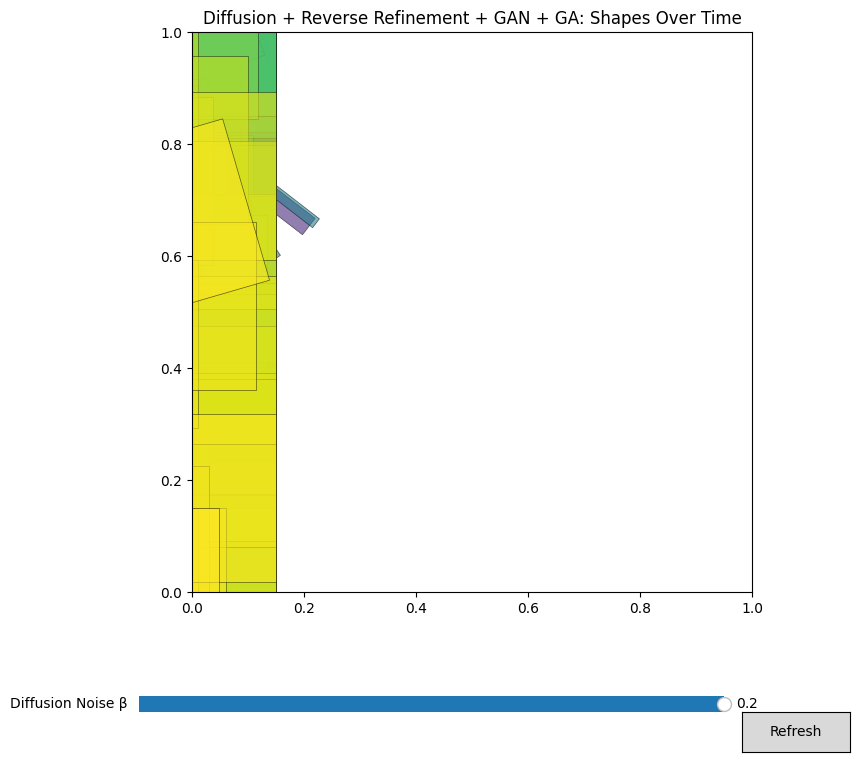

In [ ]:
"""
Diffusion (forward) + reverse-diffusion refinement + GAN + GA shape generation demo.

Requirements:
- Python 3.8+
- numpy, pandas, matplotlib, torch

Run this script. A matplotlib window will open showing generated shapes.
Use the slider at the bottom to adjust diffusion noise β.
The script prints a table (inventory) of shapes and shows a plot.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
from matplotlib.widgets import Slider, Button
import torch
import torch.nn as nn
import torch.optim as optim
import time

# -----------------------------
# Deterministic seeds
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# Diffusion Process (forward)
# -----------------------------
class DiffusionProcess:
    def __init__(self, dim=200, seed=42):
        rng = np.random.default_rng(seed)
        self.x = rng.normal(scale=0.1, size=dim).astype(np.float32)
        self.dim = dim
        self.rng = rng

    def step(self, beta):
        """
        Forward diffusion step:
        x_{t+1} = sqrt(1 - beta) * x_t + sqrt(beta) * eps
        """
        eps = self.rng.normal(size=self.dim).astype(np.float32)
        x_next = np.sqrt(1 - beta) * self.x + np.sqrt(beta) * eps
        self.x = x_next
        return self.x.copy()

    def reset(self):
        self.x[:] = 0.0

# -----------------------------
# Procedural shape utilities
# -----------------------------
SHAPE_TYPES = ["circle", "rectangle", "triangle"]

def random_shape():
    rng = np.random.default_rng()
    shape_type = rng.choice(SHAPE_TYPES)
    x, y = rng.uniform(0.1, 0.9), rng.uniform(0.1, 0.9)
    theta = rng.uniform(0, 2 * np.pi)
    if shape_type == "circle":
        r = rng.uniform(0.05, 0.15)
        return {"type": "circle", "center": (x, y), "radius": r, "orientation": theta}
    elif shape_type == "rectangle":
        w, h = rng.uniform(0.05, 0.25), rng.uniform(0.05, 0.25)
        return {"type": "rectangle", "center": (x, y), "width": w, "height": h, "orientation": theta}
    else:
        offsets = rng.uniform(-0.08, 0.08, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {"type": "triangle", "vertices": vertices, "orientation": theta}

def encode_shape(shape):
    t = np.zeros(3, dtype=np.float32)
    idx = SHAPE_TYPES.index(shape["type"])
    t[idx] = 1.0
    if shape["type"] == "circle":
        x, y = shape["center"]
        s1, s2 = shape["radius"], 0.0
    elif shape["type"] == "rectangle":
        x, y = shape["center"]
        s1, s2 = shape["width"], shape["height"]
    else:
        xs = [v[0] for v in shape["vertices"]]
        ys = [v[1] for v in shape["vertices"]]
        x, y = np.mean(xs), np.mean(ys)
        s1 = (max(xs) - min(xs))
        s2 = (max(ys) - min(ys))
    theta = shape["orientation"] / (2 * np.pi)
    return np.array([*t, x, y, s1, s2, theta], dtype=np.float32)

def decode_vector(vec):
    t_logits = vec[:3]
    t_idx = int(np.argmax(t_logits))
    shape_type = SHAPE_TYPES[t_idx]
    x = float(np.clip(vec[3], 0.0, 1.0))
    y = float(np.clip(vec[4], 0.0, 1.0))
    s1 = float(np.clip(vec[5], 0.0, 0.3))
    s2 = float(np.clip(vec[6], 0.0, 0.3))
    theta = float(np.clip(vec[7], 0.0, 1.0)) * 2 * np.pi
    if shape_type == "circle":
        return {"type": "circle", "center": (x, y), "radius": max(s1, 0.02), "orientation": theta}
    elif shape_type == "rectangle":
        return {"type": "rectangle", "center": (x, y), "width": max(s1, 0.02), "height": max(s2, 0.02), "orientation": theta}
    else:
        rng = np.random.default_rng(int((x + y) * 1e6) % 2**31)
        offsets = rng.uniform(-0.08, 0.08, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {"type": "triangle", "vertices": vertices, "orientation": theta}

# -----------------------------
# Small GAN (PyTorch MLP)
# -----------------------------
latent_dim = 8
context_dim = 32
gen_input_dim = latent_dim + context_dim
data_dim = 8

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cpu")
G = Generator(gen_input_dim, data_dim).to(device)
D = Discriminator(data_dim).to(device)
opt_G = optim.Adam(G.parameters(), lr=1e-3)
opt_D = optim.Adam(D.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# -----------------------------
# Build synthetic "real" dataset
# -----------------------------
num_real = 512
real_shapes = [random_shape() for _ in range(num_real)]
real_vecs = np.stack([encode_shape(s) for s in real_shapes], axis=0)
real_tensor = torch.tensor(real_vecs, dtype=torch.float32, device=device)
train_contexts = torch.randn(num_real, context_dim, device=device) * 0.5

# -----------------------------
# Train GAN briefly
# -----------------------------
def train_gan(epochs=12, batch_size=64):
    n = real_tensor.size(0)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            real_batch = real_tensor[idx]
            ctx = train_contexts[idx]

            # Train D
            z = torch.randn(real_batch.size(0), latent_dim, device=device)
            fake_batch = G(torch.cat([z, ctx], dim=1)).detach()
            D_real = D(real_batch)
            D_fake = D(fake_batch)
            loss_D = criterion(D_real, torch.ones_like(D_real)) + \
                     criterion(D_fake, torch.zeros_like(D_fake))
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Train G
            z = torch.randn(real_batch.size(0), latent_dim, device=device)
            fake_batch = G(torch.cat([z, ctx], dim=1))
            D_fake = D(fake_batch)
            loss_G = criterion(D_fake, torch.ones_like(D_fake))
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

train_gan()

# -----------------------------
# Diffusion -> context projection
# -----------------------------
proj_W = np.random.RandomState(SEED).normal(scale=0.5, size=(context_dim, 200)).astype(np.float32)

def diffusion_to_context(diff_state):
    return (proj_W @ diff_state).astype(np.float32)

# -----------------------------
# Reverse diffusion denoiser (simple MLP on output space)
# -----------------------------
class OutputDenoiser(nn.Module):
    def __init__(self, dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, dim),
        )
    def forward(self, x):
        return self.net(x)

denoiser = OutputDenoiser(dim=data_dim).to(device)
opt_den = optim.Adam(denoiser.parameters(), lr=1e-3)

# Train denoiser to predict noise on synthetic noisy outputs
def train_denoiser(epochs=10, batch_size=64, noise_std=0.05):
    data = real_tensor  # use real shape descriptors as "clean"
    n = data.size(0)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            clean = data[idx]
            noise = torch.randn_like(clean) * noise_std
            noisy = clean + noise
            pred_noise = denoiser(noisy)
            loss = ((pred_noise - noise) ** 2).mean()
            opt_den.zero_grad()
            loss.backward()
            opt_den.step()

train_denoiser()

def reverse_diffusion_refine(y, beta_refine=0.05, steps=3):
    """
    Simple reverse diffusion refinement on GAN output y (tensor, shape [data_dim]).
    Uses denoiser to predict noise and applies a few reverse steps.
    """
    x = y.clone()
    for _ in range(steps):
        eps_pred = denoiser(x.unsqueeze(0)).squeeze(0)
        x = (x - beta_refine * eps_pred) / np.sqrt(1.0 - beta_refine)
    return x

# -----------------------------
# Genetic Algorithm utilities
# -----------------------------
def fitness_scores(pop_z, ctx_vec, prev_z=None, use_refine=True):
    """
    Returns fitness and (optionally refined) outputs.
    """
    with torch.no_grad():
        ctx = torch.tensor(ctx_vec, dtype=torch.float32, device=device).unsqueeze(0).repeat(pop_z.size(0), 1)
        raw_out = G(torch.cat([pop_z, ctx], dim=1))  # (pop, data_dim)

        if use_refine:
            refined_list = []
            for i in range(raw_out.size(0)):
                refined_list.append(reverse_diffusion_refine(raw_out[i], beta_refine=0.05, steps=3))
            out = torch.stack(refined_list, dim=0)
        else:
            out = raw_out

        d_scores = D(out).squeeze()

        xs = torch.clamp(out[:, 3], 0.0, 1.0)
        ys = torch.clamp(out[:, 4], 0.0, 1.0)
        center_score = 1.0 - (torch.abs(xs - 0.5) + torch.abs(ys - 0.5))

        s1 = torch.clamp(out[:, 5], 0.0, 0.3)
        s2 = torch.clamp(out[:, 6], 0.0, 0.3)
        size_score = 1.0 - torch.abs((s1 + s2) / 2.0 - 0.12) * 5.0

        if prev_z is None:
            smooth_penalty = torch.zeros_like(d_scores)
        else:
            smooth_penalty = -2.0 * torch.norm(pop_z - prev_z.unsqueeze(0), dim=1)

        fit = 1.5 * d_scores + center_score + size_score + smooth_penalty
        return fit, out

def decode_out_tensor(out_tensor):
    return decode_vector(out_tensor.cpu().numpy())

# -----------------------------
# Main pipeline: diffusion drives context, GA evolves z, reverse diffusion refines outputs
# -----------------------------
def run_pipeline(beta=0.5, time_steps=200, pop_size=100, ga_gens=199):
    diff = DiffusionProcess(dim=200, seed=SEED)
    population = torch.randn(pop_size, latent_dim, device=device) * 0.8

    history = []
    prev_selected_z = None

    for t_idx in range(time_steps):
        diff_state = diff.step(beta)
        ctx = diffusion_to_context(diff_state)

        ctx_proj = torch.tensor(np.random.normal(scale=0.02, size=(latent_dim,)), dtype=torch.float32, device=device)
        population = population + ctx_proj.unsqueeze(0)

        for gen in range(ga_gens):
            fits, outs = fitness_scores(population, ctx, prev_selected_z, use_refine=True)
            k = pop_size // 2
            parents = population[torch.topk(fits, k=k).indices]

            children = []
            rng = np.random.default_rng(SEED + gen + t_idx)
            while len(children) < pop_size:
                i1, i2 = rng.integers(0, parents.size(0), size=2)
                alpha = torch.tensor(rng.random(), dtype=torch.float32, device=device)
                child = alpha * parents[i1] + (1 - alpha) * parents[i2]
                child += torch.randn_like(child) * (0.05 + 0.02 * rng.random())
                children.append(child.unsqueeze(0))
            population = torch.cat(children, dim=0)[:pop_size]

        fits, outs = fitness_scores(population, ctx, prev_selected_z, use_refine=True)
        best_idx = int(torch.argmax(fits).item())
        best_z = population[best_idx].clone().detach()
        best_out = outs[best_idx].clone().detach()
        decoded = decode_out_tensor(best_out)

        history.append({
            "id": f"t{t_idx}",
            "time": t_idx,
            "fitness": float(fits[best_idx].item()),
            "decoded": decoded
        })

        prev_selected_z = best_z.clone().detach()
        population = population + 0.1 * torch.randn_like(population)

    rows = []
    for rec in history:
        s = rec["decoded"]
        if s["type"] == "circle":
            size_str = f"r={s['radius']:.3f}"
            pos = s["center"]
        elif s["type"] == "rectangle":
            size_str = f"{s['width']:.3f}×{s['height']:.3f}"
            pos = s["center"]
        else:
            size_str = "3 vertices"
            pos = s["vertices"]
        rows.append([rec["id"], rec["time"], s["type"], pos, size_str, rec["fitness"]])

    df = pd.DataFrame(rows, columns=["ID", "Time", "Type", "Position/Vertices", "Size", "Fitness"])
    return df, history

# -----------------------------
# Plotting
# -----------------------------
def plot_history(history, ax):
    ax.clear()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Diffusion + Reverse Refinement + GAN + GA: Shapes Over Time")
    generations = max(1, max([h["time"] for h in history]) + 1)
    colors = plt.cm.viridis(np.linspace(0, 1, generations))

    for rec in history:
        s = rec["decoded"]
        t = rec["time"]
        color = colors[t]

        if s["type"] == "circle":
            ax.add_patch(Circle(s["center"], s["radius"], alpha=0.6, color=color, ec='k', linewidth=0.5))
        elif s["type"] == "rectangle":
            x, y = s["center"]
            w, h = s["width"], s["height"]
            ax.add_patch(Rectangle((x-w/2, y-h/2), w, h,
                                   angle=np.degrees(s["orientation"]),
                                   alpha=0.6, color=color, ec='k', linewidth=0.5))
        else:
            ax.add_patch(Polygon(s["vertices"], alpha=0.6, color=color, ec='k', linewidth=0.5))

    ax.set_aspect('equal', 'box')

# -----------------------------
# Interactive UI
# -----------------------------
def interactive_demo():
    init_beta = 0.50
    df, history = run_pipeline(beta=init_beta)
    print("\nInitial inventory:\n")
    print(df.to_string(index=False))

    fig = plt.figure(figsize=(9, 8))
    fig.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.12)

    ax_plot = fig.add_axes([0.08, 0.22, 0.88, 0.70])
    ax_slider = fig.add_axes([0.15, 0.06, 0.65, 0.04])
    ax_button = fig.add_axes([0.82, 0.02, 0.12, 0.05])

    plot_history(history, ax_plot)
    fig.canvas.draw_idle()

    slider = Slider(ax_slider, 'Diffusion Noise β', 0.0, 0.2, valinit=init_beta)

    def update(val):
        beta = slider.val
        t0 = time.time()
        df_new, history_new = run_pipeline(beta=beta)
        ax_plot.clear()
        plot_history(history_new, ax_plot)
        fig.canvas.draw_idle()
        print(f"\nInventory at β={beta:.4f}:\n")
        print(df_new.to_string(index=False))
        t1 = time.time()
        print(f"(Update took {t1 - t0:.2f} s)")

    slider.on_changed(update)

    def on_button(event):
        beta = slider.val
        df_new, history_new = run_pipeline(beta=beta)
        ax_plot.clear()
        plot_history(history_new, ax_plot)
        fig.canvas.draw_idle()
        print(f"\nManual refresh at β={beta:.4f}:\n")
        print(df_new.to_string(index=False))

    Button(ax_button, 'Refresh').on_clicked(on_button)

    plt.show()

if __name__ == "__main__":
    interactive_demo()

Total recorded shapes: 2500
Sample IDs: ['gen0_rank0', 'gen0_rank1', 'gen0_rank2', 'gen0_rank3', 'gen0_rank4', 'gen1_rank0', 'gen1_rank1', 'gen1_rank2', 'gen1_rank3', 'gen1_rank4']
First 3 entries: [{'type': 'rectangle', 'center': (np.float32(0.8373904), np.float32(0.7514264)), 'width': 0.02, 'height': 0.02, 'orientation': np.float32(0.0), 'time_origin': 0, 'id': 'gen0_rank0', 'latent': tensor([-0.1348,  0.8381,  0.3645,  0.7039, -0.2696,  0.6758, -0.7627,  0.0024])}, {'type': 'rectangle', 'center': (np.float32(0.8536213), np.float32(0.76627594)), 'width': 0.02, 'height': 0.02, 'orientation': np.float32(0.0), 'time_origin': 0, 'id': 'gen0_rank1', 'latent': tensor([-0.2050,  0.5585,  0.6569,  0.5414, -0.2683,  0.8033, -0.5241,  0.3625])}, {'type': 'rectangle', 'center': (np.float32(0.8778056), np.float32(0.75289816)), 'width': 0.02, 'height': 0.02, 'orientation': np.float32(0.0), 'time_origin': 0, 'id': 'gen0_rank2', 'latent': tensor([-0.5027, -0.4884,  0.1983, -0.6438,  0.0987,  0.6268

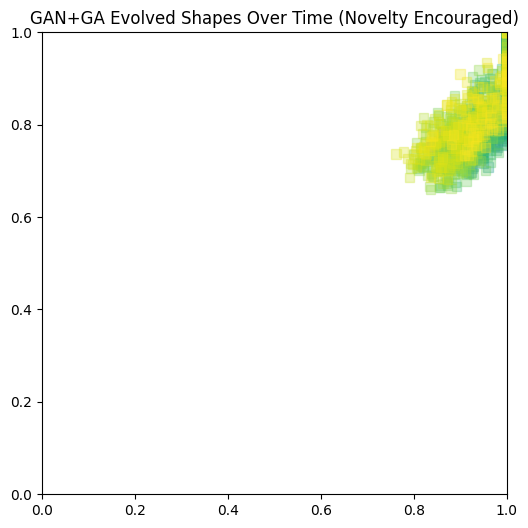

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon

import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Shape utilities
# -----------------------------

SHAPE_TYPES = ["circle", "rectangle", "triangle"]

def random_shape():
    rng = np.random.default_rng()
    shape_type = rng.choice(SHAPE_TYPES)
    x, y = rng.uniform(0.1, 0.9), rng.uniform(0.1, 0.9)
    theta = rng.uniform(0, 2 * np.pi)

    if shape_type == "circle":
        r = rng.uniform(0.05, 0.15)
        return {
            "type": "circle",
            "center": (x, y),
            "radius": r,
            "width": 0.0,
            "height": 0.0,
            "orientation": theta,
        }
    elif shape_type == "rectangle":
        w, h = rng.uniform(0.05, 0.25), rng.uniform(0.05, 0.25)
        return {
            "type": "rectangle",
            "center": (x, y),
            "radius": 0.0,
            "width": w,
            "height": h,
            "orientation": theta,
        }
    else:  # triangle
        offsets = rng.uniform(-0.1, 0.1, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {
            "type": "triangle",
            "center": (x, y),
            "radius": 0.0,
            "width": 0.0,
            "height": 0.0,
            "vertices": vertices,
            "orientation": theta,
        }

def encode_shape(shape):
    # vector: [type_one_hot(3), x, y, size1, size2, orientation_norm]
    t = np.zeros(3, dtype=np.float32)
    idx = SHAPE_TYPES.index(shape["type"])
    t[idx] = 1.0
    x, y = shape["center"]
    if shape["type"] == "circle":
        s1, s2 = shape["radius"], 0.0
    elif shape["type"] == "rectangle":
        s1, s2 = shape["width"], shape["height"]
    else:
        # approximate size by bounding box of vertices
        xs = [v[0] for v in shape["vertices"]]
        ys = [v[1] for v in shape["vertices"]]
        s1 = (max(xs) - min(xs))
        s2 = (max(ys) - min(ys))
    theta = shape["orientation"] / (2 * np.pi)  # normalize
    return np.array([*t, x, y, s1, s2, theta], dtype=np.float32)

def decode_vector(vec):
    vec = vec.detach().cpu().numpy()
    t_logits = vec[:3]
    t_idx = int(np.argmax(t_logits))
    shape_type = SHAPE_TYPES[t_idx]
    x = np.clip(vec[3], 0.0, 1.0)
    y = np.clip(vec[4], 0.0, 1.0)
    s1 = np.clip(vec[5], 0.0, 0.3)
    s2 = np.clip(vec[6], 0.0, 0.3)
    theta = (np.clip(vec[7], 0.0, 1.0)) * 2 * np.pi

    if shape_type == "circle":
        return {
            "type": "circle",
            "center": (x, y),
            "radius": max(s1, 0.02),
            "orientation": theta,
        }
    elif shape_type == "rectangle":
        return {
            "type": "rectangle",
            "center": (x, y),
            "width": max(s1, 0.02),
            "height": max(s2, 0.02),
            "orientation": theta,
        }
    else:
        # simple triangle around center
        rng = np.random.default_rng()
        offsets = rng.uniform(-0.1, 0.1, size=(3, 2))
        vertices = [(x + dx, y + dy) for dx, dy in offsets]
        return {
            "type": "triangle",
            "vertices": vertices,
            "orientation": theta,
        }

# -----------------------------
# GAN: Generator & Discriminator
# -----------------------------

latent_dim = 8
data_dim = 8  # encoded shape vector length

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, out_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cpu")

G = Generator(latent_dim, data_dim).to(device)
D = Discriminator(data_dim).to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=2e-3)
opt_D = optim.Adam(D.parameters(), lr=2e-3)

# -----------------------------
# Build synthetic "real" dataset
# -----------------------------

num_real = 512
real_shapes = [random_shape() for _ in range(num_real)]
real_vecs = np.stack([encode_shape(s) for s in real_shapes], axis=0)
real_tensor = torch.tensor(real_vecs, device=device)

# -----------------------------
# Train GAN briefly
# -----------------------------

batch_size = 200
epochs = 20

for epoch in range(epochs):
    perm = torch.randperm(num_real)
    for i in range(0, num_real, batch_size):
        idx = perm[i:i+batch_size]
        real_batch = real_tensor[idx]

        # Train D
        z = torch.randn(real_batch.size(0), latent_dim, device=device)
        fake_batch = G(z).detach()

        D_real = D(real_batch)
        D_fake = D(fake_batch)

        loss_D = criterion(D_real, torch.ones_like(D_real)) + \
                 criterion(D_fake, torch.zeros_like(D_fake))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train G
        z = torch.randn(real_batch.size(0), latent_dim, device=device)
        fake_batch = G(z)
        D_fake = D(fake_batch)
        loss_G = criterion(D_fake, torch.ones_like(D_fake))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

# -----------------------------
# Uniqueness score utility (user-provided)
# -----------------------------
def uniqueness_score(pop_z, archive_z, device):
    if len(archive_z) == 0:
        return torch.zeros(pop_z.size(0), device=device)
    arch = torch.stack(archive_z, dim=0).to(device)  # (A, latent_dim)
    # pairwise distances: (pop, A)
    dists = torch.cdist(pop_z, arch)
    # encourage being far from nearest archive member
    min_dist, _ = torch.min(dists, dim=1)
    return min_dist

# -----------------------------
# Genetic Algorithm on latent space (with uniqueness)
# -----------------------------

def fitness(z_batch, archive_z, lambda_uniq=0.8):
    with torch.no_grad():
        shapes_vec = G(z_batch)
        scores = D(shapes_vec).squeeze()  # realism score
        # Encourage center near (0.5,0.5)
        xs = torch.clamp(shapes_vec[:, 3], 0.0, 1.0)
        ys = torch.clamp(shapes_vec[:, 4], 0.0, 1.0)
        center_penalty = torch.abs(xs - 0.5) + torch.abs(ys - 0.5)
        # uniqueness reward (distance from archive)
        uniq = uniqueness_score(z_batch, archive_z, device)
        fit = scores - 0.5 * center_penalty + lambda_uniq * uniq
    return fit

pop_size = 4000
generations = 500

population = torch.randn(pop_size, latent_dim, device=device)

history_shapes = []
archive_z = []  # list of tensors (latent vectors) to encourage novelty

# GA loop
for gen in range(generations):
    # Evaluate fitness
    fits = fitness(population, archive_z, lambda_uniq=0.8)
    # Select top half
    topk = torch.topk(fits, k=pop_size // 2)
    parents = population[topk.indices]

    # Record best shapes this generation (top 5)
    # parents are ordered by descending fitness because topk returns sorted values
    best_z = parents[0:5]  # top 5
    with torch.no_grad():
        best_vecs = G(best_z)
    for j, v in enumerate(best_vecs):
        shape = decode_vector(v)
        shape["time_origin"] = gen
        shape["id"] = f"gen{gen}_rank{j}"
        # Add the latent vector to the shape record
        shape["latent"] = best_z[j].clone().detach()
        history_shapes.append(shape)

    # Add the single best latent to the archive to encourage future novelty
    # store as detached tensor on device
    best_latent = parents[0].clone().detach() # Get the very best latent from parents
    archive_z.append(best_latent)

    # Crossover + mutation to refill population
    children = []
    rng = np.random.default_rng(seed=gen + 12345)
    while len(children) < pop_size:
        # pick two parents indices
        i1 = rng.integers(0, parents.size(0))
        i2 = rng.integers(0, parents.size(0))
        p1 = parents[i1]
        p2 = parents[i2]
        alpha = torch.tensor(rng.random(), device=device, dtype=torch.float32)
        child = alpha * p1 + (1 - alpha) * p2
        # mutation
        child = child + 0.1 * torch.randn_like(child)
        children.append(child.unsqueeze(0))
    population = torch.cat(children, dim=0)[:pop_size]

print("Total recorded shapes:", len(history_shapes))
print("Sample IDs:", [s.get("id") for s in history_shapes[:10]])
print("First 3 entries:", history_shapes[:3])

# -----------------------------
# Build table of GA-generated shapes
# -----------------------------

rows = []
for s in history_shapes:
    if s["type"] == "circle":
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["center"], f"r={s['radius']:.3f}", s["orientation"],
        ])
    elif s["type"] == "rectangle":
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["center"], f"{s['width']:.3f}×{s['height']:.3f}", s["orientation"],
        ])
    else:
        rows.append([
            s["id"], s["time_origin"], s["type"],
            s["vertices"], "3 vertices", s["orientation"],
        ])

df = pd.DataFrame(rows, columns=[
    "ID", "Time", "Type", "Position/Vertices", "Size", "Orientation"
])

print("DataFrame rows:", df.shape[0])
print(df.head(20).to_string(index=False))

print("\nEvolved Shapes (GAN + GA with uniqueness):\n")
print(df.head(100))  # print first 30 rows

# -----------------------------
# Plot shapes by time of origin
# -----------------------------

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("GAN+GA Evolved Shapes Over Time (Novelty Encouraged)")

colors = plt.cm.viridis(np.linspace(0, 1, generations))

for s in history_shapes:
    t = s["time_origin"]
    color = colors[t]
    if s["type"] == "circle":
        circ = Circle(s["center"], s["radius"], alpha=0.3, color=color)
        ax.add_patch(circ)
    elif s["type"] == "rectangle":
        x, y = s["center"]
        w, h = s["width"], s["height"]
        rect = Rectangle(
            (x - w/2, y - h/2),
            w, h,
            angle=np.degrees(s["orientation"]),
            alpha=0.3,
            color=color,
        )
        ax.add_patch(rect)
    else:
        tri = Polygon(s["vertices"], alpha=0.3, color=color)
        ax.add_patch(tri)

plt.show()

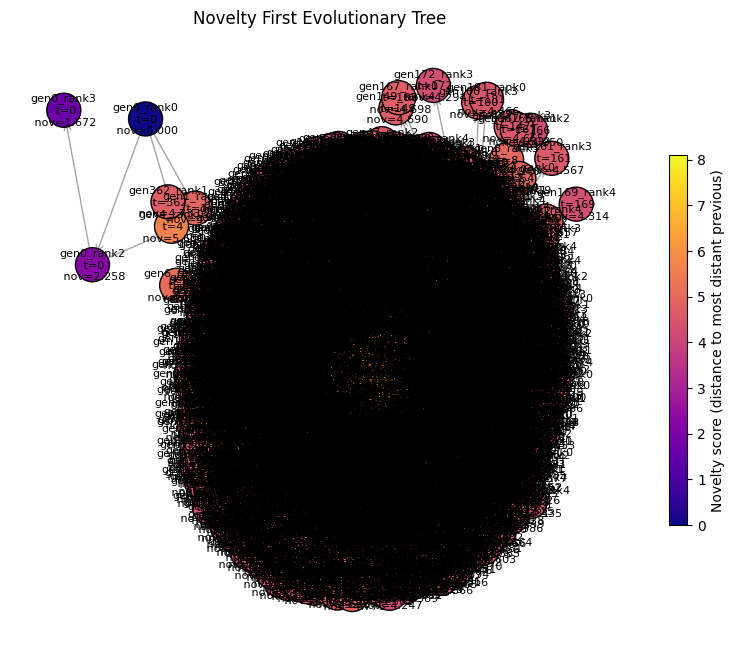

In [ ]:
# Required imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

# Example structure for history_records (populate this during GA)
# history_records = [
#     {"id":"gen0_rank0", "time_origin":0, "latent": tensor([...]), "decoded": {...}},
#     ...
# ]

def build_novelty_scores(history_records, device=torch.device("cpu")):
    """Compute novelty score for each record as distance to nearest previous record."""
    n = len(history_records)
    latents = torch.stack([r["latent"].to(device) for r in history_records], dim=0)  # (n, latent_dim)
    # pairwise distances
    dists = torch.cdist(latents, latents)  # (n, n)
    novelty = np.zeros(n, dtype=float)
    for i in range(n):
        if i == 0:
            novelty[i] = 0.0
        else:
            # only consider previous indices 0..i-1
            prev = dists[i, :i].cpu().numpy()
            novelty[i] = float(prev.max())  # distance to most distant previous (novelty)
    return novelty, dists.cpu().numpy()

def build_novelty_tree(history_records, novelty_scores, dists):
    """
    Build a directed novelty-first tree:
    For each node i (in chronological order), link to the previous node j (j < i)
    that maximizes distance dists[i,j]. If none exist (i==0), make it root.
    """
    G = nx.DiGraph()
    n = len(history_records)
    for i, rec in enumerate(history_records):
        node_id = rec["id"]
        G.add_node(node_id, time=rec.get("time_origin", None), novelty=float(novelty_scores[i]),
                   decoded=rec.get("decoded", None))
        if i == 0:
            continue
        # find previous index with maximum distance
        prev_idx = int(np.argmax(dists[i, :i]))
        parent_id = history_records[prev_idx]["id"]
        G.add_edge(parent_id, node_id, weight=float(dists[i, prev_idx]))
    return G

def plot_novelty_tree(G, history_records, figsize=(10, 8)):
    """Plot directed novelty tree with node labels and color by novelty."""
    fig, ax = plt.subplots(figsize=figsize) # Create figure and axes explicitly
    pos = nx.spring_layout(G, seed=42)  # layout; you can use hierarchical layout if desired

    # Node colors by novelty
    novelty = np.array([G.nodes[n]["novelty"] for n in G.nodes()])
    if novelty.max() > 0:
        cmap = plt.cm.plasma
        norm = plt.Normalize(vmin=novelty.min(), vmax=novelty.max())
        node_colors = [cmap(norm(G.nodes[n]["novelty"])) for n in G.nodes()]
    else:
        node_colors = "lightblue"

    # Labels: id and time
    labels = {}
    for n in G.nodes():
        t = G.nodes[n].get("time")
        nov = G.nodes[n].get("novelty")
        labels[n] = f"{n}\n t={t}\n nov={nov:.3f}"

    nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle='->', arrowsize=12, edge_color='gray', alpha=0.7)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=600, edgecolors='k')
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=8)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=novelty.min(), vmax=novelty.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6) # Pass the ax explicitly here
    cbar.set_label("Novelty score (distance to most distant previous)")

    plt.title("Novelty First Evolutionary Tree")
    plt.axis('off')
    plt.show()

# Usage example after GA
# Ensure history_records is ordered chronologically (by generation/time)
# The `history_shapes` variable from the previous cell `uZokAfzfFy7o` contains the necessary data.
# We need to ensure that the `latent` key is present in each dictionary within `history_shapes`.
# Assuming `history_shapes` now includes the 'latent' key after modification of `uZokAfzfFy7o`.
novelty_scores, pairwise_dists = build_novelty_scores(history_shapes, device=device)
G = build_novelty_tree(history_shapes, novelty_scores, pairwise_dists)
plot_novelty_tree(G, history_shapes)

In [ ]:
import csv
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
import torch

# -------------------------
# Prune graph helper
# -------------------------
def prune_graph_by_novelty(G, top_k=12):
    nov_map = {n: G.nodes[n].get("novelty", 0.0) for n in G.nodes()}
    sorted_nodes = sorted(G.nodes(), key=lambda n: nov_map[n], reverse=True)
    top_nodes = sorted_nodes[:top_k]
    nodes_to_keep = set()
    for n in top_nodes:
        nodes_to_keep.add(n)
        nodes_to_keep.update(nx.ancestors(G, n))
    if len(nodes_to_keep) == 0:
        return G.copy()
    H = G.subgraph(nodes_to_keep).copy()
    return H

# -------------------------
# Thumbnail drawing helper
# -------------------------
def draw_shape_thumbnail(ax, pos_xy, decoded, scale=0.06, alpha=0.9, edgecolor='k'):
    """
    Draw a small thumbnail of the decoded shape at normalized axes coordinates pos_xy=(x,y).
    scale controls thumbnail size in axis units (0..1).
    """
    x, y = pos_xy
    stype = decoded.get("type", "circle")
    if stype == "circle":
        r = decoded.get("radius", 0.05) * scale * 2.0
        patch = Circle((x, y), r, facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(patch)
    elif stype == "rectangle":
        cx, cy = decoded.get("center", (x, y))
        w = decoded.get("width", 0.05) * scale * 2.0
        h = decoded.get("height", 0.05) * scale * 2.0
        patch = Rectangle((x - w/2, y - h/2), w, h,
                          angle=np.degrees(decoded.get("orientation", 0.0)),
                          facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(patch)
    else:  # triangle or polygon
        verts = decoded.get("vertices", None)
        if verts is None:
            # fallback: small triangle centered at (x,y)
            verts = [(x - 0.02*scale, y - 0.02*scale),
                     (x + 0.02*scale, y - 0.02*scale),
                     (x, y + 0.03*scale)]
        # ensure vertices are in axis coordinates; if they look like absolute coords (0..1) use them directly
        poly = Polygon(verts, closed=True, facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(poly)

# -------------------------
# Plot pruned novelty tree with thumbnails
# -------------------------
def plot_pruned_novelty_tree_with_thumbnails(G, history_records, top_k=12, figsize=(10, 8)):
    """
    Prune G to top_k novel nodes + ancestors, then plot with thumbnails for labeled nodes.
    """
    H = prune_graph_by_novelty(G, top_k=top_k)
    nodes = list(H.nodes())
    if len(nodes) == 0:
        print("No nodes to plot.")
        return

    # novelty array and normalization
    novelty = np.array([H.nodes[n].get("novelty", 0.0) for n in nodes])
    if novelty.max() > novelty.min():
        norm = plt.Normalize(vmin=novelty.min(), vmax=novelty.max())
    else:
        norm = plt.Normalize(vmin=0.0, vmax=1.0)
    cmap = plt.cm.plasma

    # Attempt layered layout by time if available
    times = [H.nodes[n].get("time", None) for n in nodes]
    pos = {}
    if all(t is not None for t in times):
        unique_times = sorted(list({H.nodes[n]["time"] for n in nodes}))
        for layer_idx, t in enumerate(unique_times):
            layer_nodes = [n for n in nodes if H.nodes[n]["time"] == t]
            m = len(layer_nodes)
            if m == 0:
                continue
            xs = np.linspace(0.08, 0.92, m)
            y = 0.95 - (layer_idx / max(1, len(unique_times)-1)) * 0.8
            for i, n in enumerate(layer_nodes):
                pos[n] = np.array([xs[i], y])
        remaining = [n for n in nodes if n not in pos]
        if remaining:
            spring_pos = nx.spring_layout(H.subgraph(remaining), seed=42, k=0.6)
            for n, p in spring_pos.items():
                pos[n] = p
    else:
        pos = nx.spring_layout(H, seed=42, k=0.6)

    # Node sizes and colors
    min_size, max_size = 200, 1200
    if novelty.max() > novelty.min():
        sizes = min_size + ((novelty - novelty.min()) / (novelty.max() - novelty.min())) * (max_size - min_size)
    else:
        sizes = np.full_like(novelty, (min_size + max_size) / 2.0)
    node_colors = [cmap(norm(H.nodes[n].get("novelty", 0.0))) for n in nodes]

    # Choose label nodes (top novel nodes)
    sorted_by_nov = sorted(nodes, key=lambda n: H.nodes[n].get("novelty", 0.0), reverse=True)
    label_nodes = set(sorted_by_nov[:min(top_k, len(nodes))])

    labels = {}
    for n in nodes:
        if n in label_nodes:
            t = H.nodes[n].get("time")
            nov = H.nodes[n].get("novelty", 0.0)
            short_id = str(n) if len(str(n)) <= 12 else str(n)[:10] + "…"
            labels[n] = f"{short_id}\n t={t}\n nov={nov:.2f}"
        else:
            labels[n] = ""

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title("Sparse Novelty‑First Evolutionary Tree (Top novel nodes + ancestors)")

    nx.draw_networkx_edges(H, pos, ax=ax, arrowstyle='-|>', arrowsize=10, edge_color='gray', alpha=0.45, width=0.8)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors, node_size=sizes, edgecolors='k', linewidths=0.6)
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

    # Draw thumbnails for labeled nodes (use decoded shapes from history_records)
    id_to_record = {rec["id"]: rec for rec in history_records}
    for n in label_nodes:
        rec = id_to_record.get(n, None)
        if rec is None:
            continue
        decoded = rec.get("decoded", None)
        if decoded is None:
            continue
        # pos[n] may be numpy array; ensure in axis coords
        p = pos[n]
        # If spring_layout returned large coordinates, normalize positions to [0,1] box for thumbnail placement
        # Compute bounding box of pos and normalize
    # Normalize positions to [0,1] for thumbnail placement
    all_pos = np.array([pos[n] for n in nodes])
    min_xy = all_pos.min(axis=0)
    max_xy = all_pos.max(axis=0)
    span = max_xy - min_xy
    span[span == 0] = 1.0
    norm_pos = {n: ((pos[n] - min_xy) / span) for n in nodes}

    for n in label_nodes:
        rec = id_to_record.get(n, None)
        if rec is None:
            continue
        decoded = rec.get("decoded", None)
        if decoded is None:
            continue
        p_norm = norm_pos[n]
        draw_shape_thumbnail(ax, (p_norm[0], p_norm[1]), decoded, scale=0.06, alpha=0.95, edgecolor='k')

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(novelty)
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
    cbar.set_label("Novelty (distance to most distant previous)")

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# -------------------------
# Export adjacency CSV
# -------------------------
def export_pruned_adjacency_csv(G, history_records, top_k=12, csv_path="pruned_tree_adjacency.csv"):
    """
    Export edges of the pruned novelty-first tree as CSV with columns:
      parent_id, child_id, weight
    """
    H = prune_graph_by_novelty(G, top_k=top_k)
    rows = []
    for u, v, data in H.edges(data=True):
        weight = data.get("weight", "")
        rows.append((u, v, weight))
    # Write CSV
    with open(csv_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["parent_id", "child_id", "weight"])
        for r in rows:
            writer.writerow(r)
    return csv_path

# -------------------------
# Usage example (after building G and history_records)
# -------------------------
# novelty_scores, pairwise_dists = build_novelty_scores(history_records, device=device)
# G = build_novelty_tree(history_records, novelty_scores, pairwise_dists)
# plot_pruned_novelty_tree_with_thumbnails(G, history_records, top_k=12, figsize=(12,8))
# csv_file = export_pruned_adjacency_csv(G, history_records, top_k=12, csv_path="novelty_tree.csv")
# print("Exported adjacency CSV to:", csv_file)


How this changes behavior: the system will seek out new regions of latent space

You’ll see more diverse shapes over time

Temporal coherence will drop, but creative jumps will increase

GA becomes more of a novelty search than a stabilizer



Keep realism from discriminator, geometric desirability; remove smoothness; add uniqueness/creativity and reward large jumps or novelty.

So instead of:

fitness = 1.5𝐷 + center + size−2∥𝑧−𝑧_prev∥

We move to something like:

fitness = 1.5𝐷 + center + size + 𝜆_uniq ⋅ uniqueness(𝑧)

In [ ]:
"""
Hypergraph from GA latents with thumbnail visualization and CSV export.

Requirements:
- Python 3.8+
- numpy, matplotlib, networkx, sklearn, torch, pandas

Inputs:
- history_records: list of dicts, chronological, each dict must contain:
    "id"         : unique string id for the shape (e.g., "gen12_rank0")
    "latent"     : 1D torch tensor (latent_dim,)
    "decoded"    : dict with decoded shape (keys: "type", "center"/"vertices", "radius"/"width"/"height", "orientation")
Example:
    history_records = [
        {"id":"gen0_rank0", "time_origin":0, "latent": tensor([...]), "decoded": {...}},
        ...
    ]
"""

import csv
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
from sklearn.cluster import DBSCAN
import torch
import pandas as pd

# -------------------------
# Thumbnail helper (same style as earlier)
# -------------------------
def draw_shape_thumbnail(ax, pos_xy, decoded, scale=0.04, alpha=0.95, edgecolor='k'):
    x, y = pos_xy
    stype = decoded.get("type", "circle")
    if stype == "circle":
        r = decoded.get("radius", 0.05) * scale * 2.0
        patch = Circle((x, y), r, facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(patch)
    elif stype == "rectangle":
        cx, cy = decoded.get("center", (x, y))
        w = decoded.get("width", 0.05) * scale * 2.0
        h = decoded.get("height", 0.05) * scale * 2.0
        patch = Rectangle((x - w/2, y - h/2), w, h,
                          angle=np.degrees(decoded.get("orientation", 0.0)),
                          facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(patch)
    else:
        verts = decoded.get("vertices", None)
        if verts is None:
            verts = [(x - 0.02*scale, y - 0.02*scale),
                     (x + 0.02*scale, y - 0.02*scale),
                     (x, y + 0.03*scale)]
        poly = Polygon(verts, closed=True, facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(poly)

# -------------------------
# Build hypergraph (bipartite) from history_records
# -------------------------
def build_hypergraph(history_records, cluster_eps=1.0, cluster_min_samples=2, novelty_k=3, device=torch.device("cpu")):
    """
    Returns:
      B : networkx.Graph (bipartite) with shape nodes (prefix 's:') and hyperedge nodes (prefix 'h:')
      meta: dict with metadata (cluster_labels, pairwise_dists, hyperedge_info)
    """
    # Prepare latent matrix
    latents = torch.stack([r["latent"].to(device) for r in history_records], dim=0).cpu().numpy()  # (N, D)
    ids = [r["id"] for r in history_records]
    N = latents.shape[0]

    # Pairwise distances (Euclidean)
    from scipy.spatial.distance import cdist
    dists = cdist(latents, latents, metric='euclidean')

    # 1) Cluster hyperedges via DBSCAN
    db = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit(latents)
    labels = db.labels_  # -1 = noise
    cluster_map = {}
    for i, lab in enumerate(labels):
        if lab == -1:
            continue
        cluster_map.setdefault(lab, []).append(ids[i])

    # 2) Novelty hyperedges: for each node, connect to its top novelty_k most distant previous nodes
    novelty_map = {}
    for i in range(N):
        # consider all other nodes (or only previous ones if you want chronological)
        # here we use all nodes but exclude self
        idxs = np.argsort(-dists[i])  # descending distances
        # skip self (first)
        idxs = idxs[idxs != i]
        topk = idxs[:novelty_k]
        members = [ids[i]] + [ids[j] for j in topk]
        novelty_map[ids[i]] = members

    # Build bipartite graph
    B = nx.Graph()
    # Add shape nodes
    for r in history_records:
        node = f"s:{r['id']}"
        B.add_node(node, bipartite=0, kind='shape', decoded=r.get("decoded", None), time=r.get("time_origin", None))

    hyperedge_info = []

    # Add cluster hyperedges
    for lab, members in cluster_map.items():
        hid = f"h:cluster_{lab}"
        B.add_node(hid, bipartite=1, kind='cluster', label=f"cluster_{lab}")
        for m in members:
            B.add_edge(hid, f"s:{m}", weight=1.0)
        hyperedge_info.append({"id": hid, "type": "cluster", "members": members, "weight": None})

    # Add novelty hyperedges
    for center_id, members in novelty_map.items():
        hid = f"h:novel_{center_id}"
        B.add_node(hid, bipartite=1, kind='novelty', label=f"novel_{center_id}")
        # weight = distances from center to each member (for CSV)
        weights = []
        for m in members:
            j = ids.index(m)
            i = ids.index(center_id)
            w = float(dists[i, j])
            weights.append(w)
            B.add_edge(hid, f"s:{m}", weight=w)
        hyperedge_info.append({"id": hid, "type": "novelty", "members": members, "weight": np.mean(weights)})

    meta = {
        "latents": latents,
        "ids": ids,
        "pairwise_dists": dists,
        "cluster_labels": labels,
        "hyperedge_info": hyperedge_info
    }
    return B, meta

# -------------------------
# Visualize hypergraph with thumbnails
# -------------------------
def plot_hypergraph_with_thumbnails(B, history_records, meta, top_hyperedges=12, figsize=(12, 9)):
    """
    Visualize the bipartite hypergraph:
      - shape nodes as thumbnails
      - hyperedge nodes as squares
      - only show top_hyperedges by mean weight or cluster size for readability
    """
    # Select hyperedges to show (rank by weight or size)
    hedges = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]
    # compute score for each hyperedge
    hedge_scores = []
    for h in hedges:
        members = [nbr for nbr in B.neighbors(h)]
        weights = [B.edges[h, m].get("weight", 1.0) for m in members]
        score = np.mean(weights) if len(weights) > 0 else 0.0
        hedge_scores.append((h, score, len(members)))
    # sort by (size desc, score desc) to prefer larger groups
    hedge_scores = sorted(hedge_scores, key=lambda x: (x[2], x[1]), reverse=True)
    selected_hedges = [h for h,_,_ in hedge_scores[:top_hyperedges]]

    # Build subgraph containing selected hyperedges and their member shapes
    nodes_to_keep = set(selected_hedges)
    for h in selected_hedges:
        nodes_to_keep.update(B.neighbors(h))
    H = B.subgraph(nodes_to_keep).copy()

    # Layout: place shape nodes on a circle, hyperedges near centroid of their members
    shape_nodes = [n for n, d in H.nodes(data=True) if d.get("kind") == 'shape']
    hedge_nodes = [n for n, d in H.nodes(data=True) if d.get("kind") != 'shape']

    # circle layout for shapes
    n_shapes = len(shape_nodes)
    theta = np.linspace(0, 2*np.pi, max(1, n_shapes), endpoint=False)
    shape_pos = {}
    for i, n in enumerate(shape_nodes):
        r = 0.38 + 0.02 * (i % 3)  # slight radius jitter
        shape_pos[n] = np.array([0.5 + r * np.cos(theta[i % len(theta)]), 0.5 + r * np.sin(theta[i % len(theta)])])

    # hyperedge positions: centroid of member shapes
    pos = dict(shape_pos)
    for h in hedge_nodes:
        members = list(H.neighbors(h))
        coords = np.array([pos[m] for m in members if m in pos])
        if coords.size == 0:
            pos[h] = np.array([0.5, 0.5])
        else:
            centroid = coords.mean(axis=0)
            # push hyperedge slightly outward from center for readability
            vec = centroid - np.array([0.5, 0.5])
            pos[h] = centroid + 0.12 * (vec / (np.linalg.norm(vec) + 1e-6))

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title("Hypergraph of GA Shapes (clusters + novelty hyperedges)")

    # Draw hyperedge nodes as squares
    for h in hedge_nodes:
        x, y = pos[h]
        size = 0.04
        rect = Rectangle((x - size/2, y - size/2), size, size, facecolor='lightgray', edgecolor='k', alpha=0.9, linewidth=0.8)
        ax.add_patch(rect)
        # label hyperedge
        label = H.nodes[h].get("label", h)
        ax.text(x, y + 0.05, label, ha='center', va='bottom', fontsize=8, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    # Draw edges from hyperedge to member shapes
    for h in hedge_nodes:
        for m in H.neighbors(h):
            hx, hy = pos[h]
            mx, my = pos[m]
            ax.plot([hx, mx], [hy, my], color='gray', linewidth=0.8, alpha=0.6)

    # Draw shape thumbnails
    id_to_record = {rec["id"]: rec for rec in history_records}
    for s in shape_nodes:
        sid = s.split("s:")[-1]
        rec = id_to_record.get(sid, None)
        if rec is None:
            continue
        decoded = rec.get("decoded", None)
        p = pos[s]
        draw_shape_thumbnail(ax, (p[0], p[1]), decoded, scale=0.06, alpha=0.95, edgecolor='k')
        # small label
        ax.text(p[0], p[1] - 0.06, sid, ha='center', va='top', fontsize=7, alpha=0.8)

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# -------------------------
# Export hyperedge membership CSV
# -------------------------
def export_hyperedges_csv(B, csv_path="hyperedges_membership.csv"):
    """
    CSV columns: hyperedge_id, hyperedge_type, member_id, weight
    """
    rows = []
    for n, d in B.nodes(data=True):
        if d.get("bipartite") == 1:
            hid = n
            htype = d.get("kind", "")
            for m in B.neighbors(hid):
                weight = B.edges[hid, m].get("weight", "")
                member_id = m.split("s:")[-1]
                rows.append((hid, htype, member_id, weight))
    df = pd.DataFrame(rows, columns=["hyperedge_id", "hyperedge_type", "member_id", "weight"])
    df.to_csv(csv_path, index=False)
    return csv_path

# -------------------------
# Example usage (after GA)
# -------------------------
# history_records must be prepared as described at top.
# B, meta = build_hypergraph(history_records, cluster_eps=0.8, cluster_min_samples=2, novelty_k=3)
# plot_hypergraph_with_thumbnails(B, history_records, meta, top_hyperedges=12)
# csv_file = export_hyperedges_csv(B, csv_path="hyperedges_membership.csv")
# print("Exported hyperedges CSV to:", csv_file)

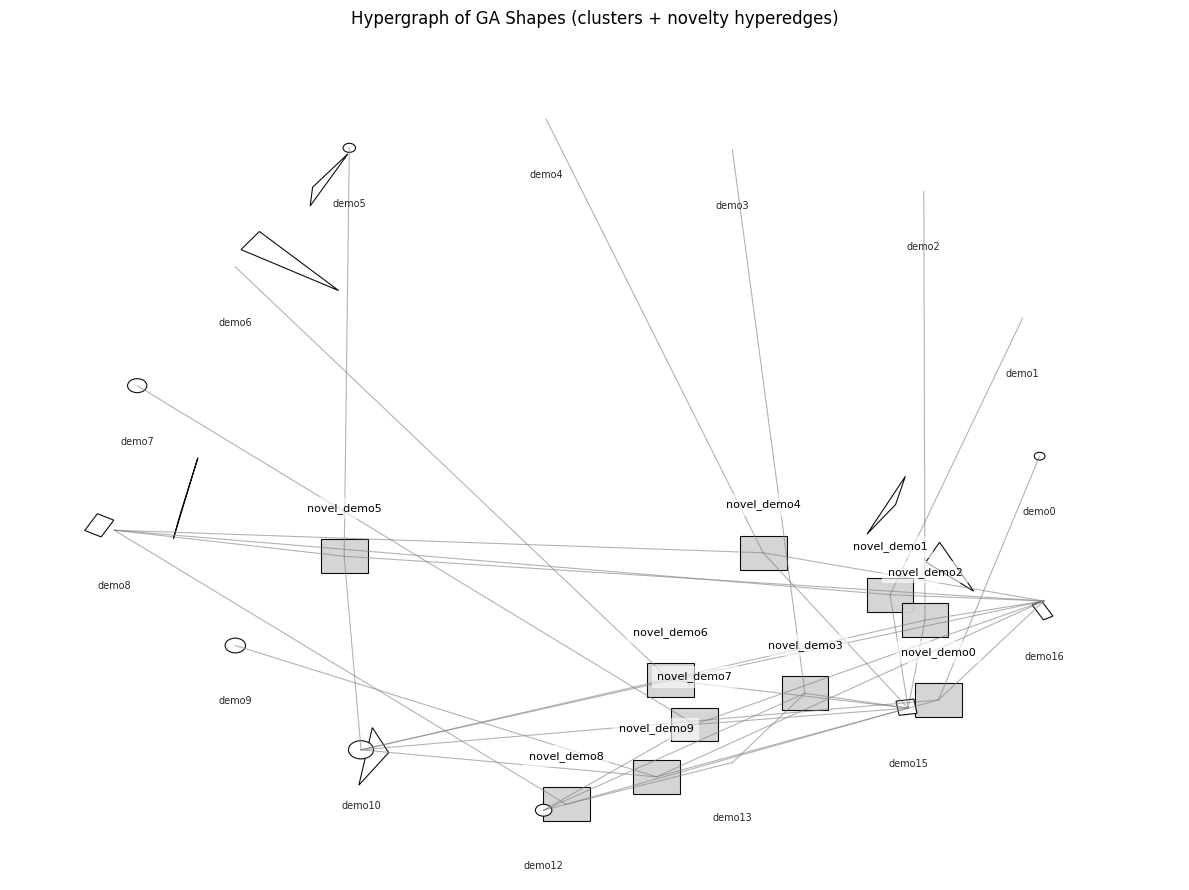

In [ ]:
"""
Hypergraph visualization for GA-generated shapes.

Input:
  - history_records: list of dicts, chronological, each dict must contain:
      "id"       : unique string id (e.g., "gen12_rank0")
      "latent"   : 1D torch tensor (latent_dim,)
      "decoded"  : dict with decoded shape (keys: "type", "center"/"vertices", "radius"/"width"/"height", "orientation")
Example:
  history_records = [
      {"id":"gen0_rank0", "time_origin":0, "latent": tensor([...]), "decoded": {...}},
      ...
  ]

Run the script to display an interactive matplotlib figure.
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
from sklearn.cluster import DBSCAN
import torch
from scipy.spatial.distance import cdist

# -------------------------
# Thumbnail helper
# -------------------------
def draw_shape_thumbnail(ax, pos_xy, decoded, scale=0.05, alpha=0.95, edgecolor='k'):
    x, y = float(pos_xy[0]), float(pos_xy[1])
    stype = decoded.get("type", "circle")
    if stype == "circle":
        r = float(decoded.get("radius", 0.05)) * scale * 2.0
        patch = Circle((x, y), r, facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(patch)
    elif stype == "rectangle":
        cx, cy = decoded.get("center", (x, y))
        w = float(decoded.get("width", 0.05)) * scale * 2.0
        h = float(decoded.get("height", 0.05)) * scale * 2.0
        patch = Rectangle((x - w/2, y - h/2), w, h,
                          angle=np.degrees(decoded.get("orientation", 0.0)),
                          facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(patch)
    else:
        verts = decoded.get("vertices", None)
        if verts is None:
            verts = [(x - 0.02*scale, y - 0.02*scale),
                     (x + 0.02*scale, y - 0.02*scale),
                     (x, y + 0.03*scale)]
        poly = Polygon(verts, closed=True, facecolor='white', edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        ax.add_patch(poly)

# -------------------------
# Build bipartite hypergraph
# -------------------------
def build_hypergraph(history_records, cluster_eps=0.8, cluster_min_samples=2, novelty_k=3, device=torch.device("cpu")):
    """
    Build a bipartite graph B:
      - shape nodes: 's:<id>'
      - hyperedge nodes: 'h:cluster_<lab>' and 'h:novel_<center_id>'
    Returns (B, meta)
    """
    if len(history_records) == 0:
        return nx.Graph(), {}

    ids = [r["id"] for r in history_records]
    latents = torch.stack([r["latent"].to(device) for r in history_records], dim=0).cpu().numpy()
    dists = cdist(latents, latents, metric='euclidean')

    # DBSCAN clusters
    db = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit(latents)
    labels = db.labels_

    B = nx.Graph()
    # add shape nodes
    for r in history_records:
        node = f"s:{r['id']}"
        B.add_node(node, bipartite=0, kind='shape', decoded=r.get("decoded", None), time=r.get("time_origin", None))

    # cluster hyperedges
    cluster_map = {}
    for i, lab in enumerate(labels):
        if lab == -1:
            continue
        cluster_map.setdefault(int(lab), []).append(ids[i])
    for lab, members in cluster_map.items():
        hid = f"h:cluster_{lab}"
        B.add_node(hid, bipartite=1, kind='cluster', label=f"cluster_{lab}")
        for m in members:
            B.add_edge(hid, f"s:{m}", weight=1.0)

    # novelty hyperedges: for each node, connect to its top novelty_k most distant nodes
    for i, center_id in enumerate(ids):
        idxs = np.argsort(-dists[i])
        idxs = idxs[idxs != i]
        topk = idxs[:novelty_k]
        members = [center_id] + [ids[j] for j in topk]
        hid = f"h:novel_{center_id}"
        B.add_node(hid, bipartite=1, kind='novelty', label=f"novel_{center_id}")
        for m in members:
            j = ids.index(m)
            w = float(dists[i, j])
            B.add_edge(hid, f"s:{m}", weight=w)

    meta = {"ids": ids, "latents": latents, "pairwise_dists": dists, "cluster_labels": labels}
    return B, meta

# -------------------------
# Visualize hypergraph with thumbnails
# -------------------------
def plot_hypergraph(B, history_records, top_hyperedges=12, figsize=(12, 9)):
    """
    Visualize a bipartite hypergraph:
      - show up to top_hyperedges (ranked by size) for readability
      - shape nodes drawn as thumbnails; hyperedges as squares
    """
    if B.number_of_nodes() == 0:
        print("Empty graph: nothing to plot.")
        return

    # collect hyperedge nodes and score them by size
    hedges = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]
    hedge_info = []
    for h in hedges:
        members = list(B.neighbors(h))
        score = len(members)
        hedge_info.append((h, score))
    hedge_info = sorted(hedge_info, key=lambda x: x[1], reverse=True)
    selected_hedges = [h for h, _ in hedge_info[:top_hyperedges]]

    # build subgraph
    nodes_to_keep = set(selected_hedges)
    for h in selected_hedges:
        nodes_to_keep.update(B.neighbors(h))
    H = B.subgraph(nodes_to_keep).copy()

    # separate nodes
    shape_nodes = [n for n, d in H.nodes(data=True) if d.get("kind") == 'shape']
    hedge_nodes = [n for n, d in H.nodes(data=True) if d.get("kind") != 'shape']

    # layout: place shape nodes on a circle, hyperedges near centroid of their members
    n_shapes = max(1, len(shape_nodes))
    theta = np.linspace(0, 2*np.pi, n_shapes, endpoint=False)
    shape_pos = {}
    for i, n in enumerate(shape_nodes):
        r = 0.38 + 0.02 * (i % 3)
        shape_pos[n] = np.array([0.5 + r * np.cos(theta[i]), 0.5 + r * np.sin(theta[i])])

    pos = dict(shape_pos)
    for h in hedge_nodes:
        members = [m for m in H.neighbors(h) if m in pos]
        if len(members) == 0:
            pos[h] = np.array([0.5, 0.5])
            continue
        coords = np.array([pos[m] for m in members])
        centroid = coords.mean(axis=0)
        vec = centroid - np.array([0.5, 0.5])
        pos[h] = centroid + 0.12 * (vec / (np.linalg.norm(vec) + 1e-6))

    # plotting
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title("Hypergraph of GA Shapes (clusters + novelty hyperedges)")

    # draw hyperedge squares and labels
    for h in hedge_nodes:
        x, y = pos[h]
        size = 0.04
        rect = Rectangle((x - size/2, y - size/2), size, size, facecolor='lightgray', edgecolor='k', alpha=0.95, linewidth=0.8)
        ax.add_patch(rect)
        label = H.nodes[h].get("label", h)
        ax.text(x, y + 0.05, label, ha='center', va='bottom', fontsize=8, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    # draw edges
    for h in hedge_nodes:
        for m in H.neighbors(h):
            hx, hy = pos[h]
            mx, my = pos[m]
            ax.plot([hx, mx], [hy, my], color='gray', linewidth=0.8, alpha=0.6)

    # draw thumbnails for shapes and small labels
    id_to_record = {rec["id"]: rec for rec in history_records}
    for s in shape_nodes:
        sid = s.split("s:")[-1]
        rec = id_to_record.get(sid, None)
        if rec is None:
            continue
        decoded = rec.get("decoded", None)
        p = pos[s]
        draw_shape_thumbnail(ax, (p[0], p[1]), decoded, scale=0.06, alpha=0.95, edgecolor='k')
        ax.text(p[0], p[1] - 0.06, sid, ha='center', va='top', fontsize=7, alpha=0.85)

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# -------------------------
# Demo: create a small synthetic history_records if not provided
# -------------------------
def _make_demo_history(n=12, latent_dim=8, seed=42):
    rng = np.random.default_rng(seed)
    recs = []
    for i in range(n):
        shape_type = rng.choice(["circle", "rectangle", "triangle"])
        x, y = rng.uniform(0.15, 0.85), rng.uniform(0.15, 0.85)
        theta = rng.uniform(0, 2*np.pi)
        if shape_type == "circle":
            decoded = {"type":"circle", "center":(x,y), "radius":rng.uniform(0.03,0.12), "orientation":theta}
        elif shape_type == "rectangle":
            decoded = {"type":"rectangle", "center":(x,y), "width":rng.uniform(0.04,0.2), "height":rng.uniform(0.04,0.2), "orientation":theta}
        else:
            offsets = rng.uniform(-0.06, 0.06, size=(3,2))
            verts = [(x+dx, y+dy) for dx,dy in offsets]
            decoded = {"type":"triangle", "vertices":verts, "orientation":theta}
        latent = torch.tensor(rng.normal(size=(latent_dim,)).astype(np.float32))
        recs.append({"id":f"demo{i}", "time_origin":i, "latent":latent, "decoded":decoded})
    return recs

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    # If you already have history_records in your environment, skip demo creation:
    try:
        history_records  # noqa: F821
    except NameError:
        history_records = _make_demo_history(n=18)

    B, meta = build_hypergraph(history_records, cluster_eps=1.0, cluster_min_samples=2, novelty_k=3)
    plot_hypergraph(B, history_records, top_hyperedges=10, figsize=(12, 9))

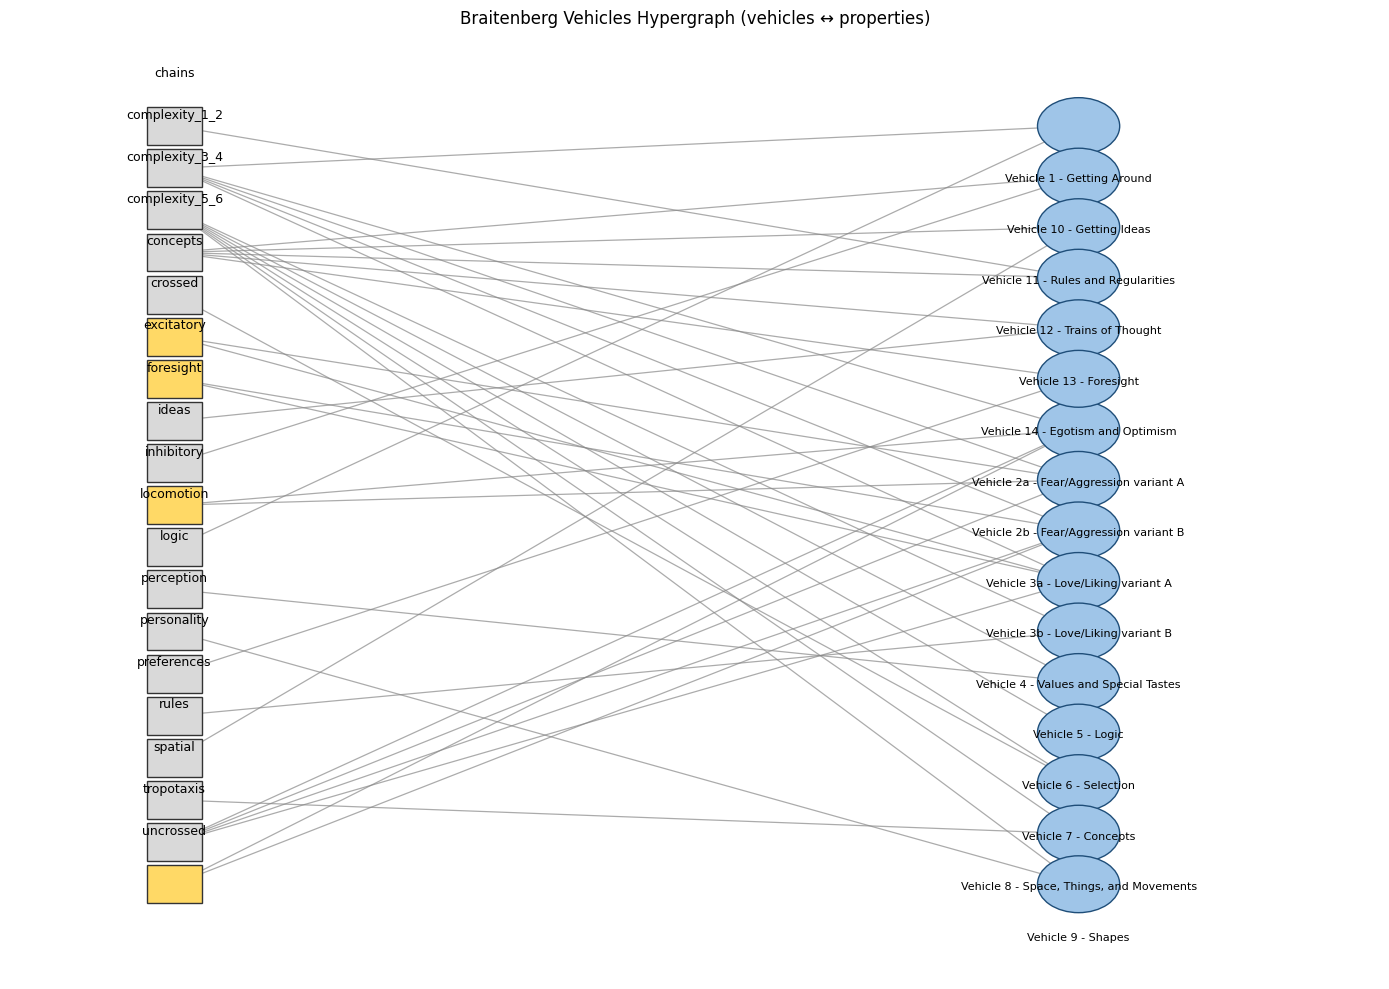

Exported hyperedges CSV to: braitenberg_hyperedges.csv


In [ ]:
"""
Visualize a hypergraph of Braitenberg Vehicles (Vehicles: Experiments in Synthetic Psychology).
- Nodes: vehicles (s:vehicle_id)
- Hyperedges: properties/groups (h:property)
- Visualization: bipartite layout with vehicle labels and hyperedge squares
- CSV export: hyperedge_id, hyperedge_type, member_id

Requires: networkx, matplotlib, pandas, numpy
"""

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import numpy as np
import csv

# -------------------------
# 1) Define vehicles and properties
# -------------------------
# Minimal canonical list (chapter headings / vehicle numbers)
vehicles = [
    {"id": "V1", "name": "Vehicle 1 - Getting Around", "theme": "locomotion", "complexity": 1},
    {"id": "V2a", "name": "Vehicle 2a - Fear/Aggression variant A", "theme": "tropotaxis", "wiring": "uncrossed", "sign": "inhibitory", "complexity": 2},
    {"id": "V2b", "name": "Vehicle 2b - Fear/Aggression variant B", "theme": "tropotaxis", "wiring": "crossed", "sign": "inhibitory", "complexity": 2},
    {"id": "V3a", "name": "Vehicle 3a - Love/Liking variant A", "theme": "tropotaxis", "wiring": "uncrossed", "sign": "excitatory", "complexity": 2},
    {"id": "V3b", "name": "Vehicle 3b - Love/Liking variant B", "theme": "tropotaxis", "wiring": "crossed", "sign": "excitatory", "complexity": 2},
    {"id": "V4", "name": "Vehicle 4 - Values and Special Tastes", "theme": "preferences", "complexity": 3},
    {"id": "V5", "name": "Vehicle 5 - Logic", "theme": "logic", "complexity": 3},
    {"id": "V6", "name": "Vehicle 6 - Selection", "theme": "selection", "complexity": 3},
    {"id": "V7", "name": "Vehicle 7 - Concepts", "theme": "concepts", "complexity": 4},
    {"id": "V8", "name": "Vehicle 8 - Space, Things, and Movements", "theme": "spatial", "complexity": 4},
    {"id": "V9", "name": "Vehicle 9 - Shapes", "theme": "perception", "complexity": 4},
    {"id": "V10", "name": "Vehicle 10 - Getting Ideas", "theme": "ideas", "complexity": 5},
    {"id": "V11", "name": "Vehicle 11 - Rules and Regularities", "theme": "rules", "complexity": 5},
    {"id": "V12", "name": "Vehicle 12 - Trains of Thought", "theme": "chains", "complexity": 5},
    {"id": "V13", "name": "Vehicle 13 - Foresight", "theme": "foresight", "complexity": 6},
    {"id": "V14", "name": "Vehicle 14 - Egotism and Optimism", "theme": "personality", "complexity": 6},
]

# Define hyperedge groups (properties) we want to visualize
hyperedges = {
    # wiring / sign groups (early vehicles)
    "uncrossed": {"type": "wiring"},
    "crossed": {"type": "wiring"},
    "excitatory": {"type": "sign"},
    "inhibitory": {"type": "sign"},
    # thematic groups
    "locomotion": {"type": "theme"},
    "tropotaxis": {"type": "theme"},
    "preferences": {"type": "theme"},
    "logic": {"type": "theme"},
    "concepts": {"type": "theme"},
    "spatial": {"type": "theme"},
    "perception": {"type": "theme"},
    "ideas": {"type": "theme"},
    "rules": {"type": "theme"},
    "chains": {"type": "theme"},
    "foresight": {"type": "theme"},
    "personality": {"type": "theme"},
    # complexity bands
    "complexity_1_2": {"type": "complexity"},
    "complexity_3_4": {"type": "complexity"},
    "complexity_5_6": {"type": "complexity"},
}

# -------------------------
# 2) Build bipartite hypergraph (as a graph: hyperedge nodes connect to member vehicle nodes)
# -------------------------
B = nx.Graph()

# add vehicle nodes (prefix 's:')
for v in vehicles:
    node = f"s:{v['id']}"
    B.add_node(node, bipartite=0, kind="vehicle", label=v["name"], **v)

# add hyperedge nodes (prefix 'h:')
for h, meta in hyperedges.items():
    node = f"h:{h}"
    B.add_node(node, bipartite=1, kind="hyperedge", label=h, **meta)

# connect vehicles to hyperedges based on attributes
for v in vehicles:
    vid = f"s:{v['id']}"
    # theme
    theme = v.get("theme")
    if theme and f"h:{theme}" in B:
        B.add_edge(f"h:{theme}", vid, weight=1.0)
    # wiring/sign if present
    wiring = v.get("wiring")
    sign = v.get("sign")
    if wiring and f"h:{wiring}" in B:
        B.add_edge(f"h:{wiring}", vid, weight=1.0)
    if sign and f"h:{sign}" in B:
        B.add_edge(f"h:{sign}", vid, weight=1.0)
    # complexity band
    c = v.get("complexity", 0)
    if c <= 2:
        B.add_edge("h:complexity_1_2", vid, weight=1.0)
    elif c <= 4:
        B.add_edge("h:complexity_3_4", vid, weight=1.0)
    else:
        B.add_edge("h:complexity_5_6", vid, weight=1.0)

# -------------------------
# 3) Visualization function
# -------------------------
def plot_hypergraph(B, figsize=(12, 8), show_labels=True, highlight_hyperedges=None):
    """
    Visualize bipartite hypergraph:
      - vehicle nodes as circles with labels
      - hyperedge nodes as squares
      - edges connect hyperedges to member vehicles
    highlight_hyperedges: list of hyperedge keys (without 'h:') to emphasize
    """
    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title("Braitenberg Vehicles Hypergraph (vehicles ↔ properties)")

    # split nodes
    shape_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 0]
    hedge_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]

    # layout: place hyperedges on left column, vehicles on right column, vertical spacing by count
    left_x = 0.12
    right_x = 0.78
    # hyperedge positions
    hy_count = len(hedge_nodes)
    hy_ys = np.linspace(0.9, 0.1, hy_count)
    pos = {}
    for i, h in enumerate(sorted(hedge_nodes)):
        pos[h] = np.array([left_x, hy_ys[i]])
    # vehicle positions
    v_count = len(shape_nodes)
    v_ys = np.linspace(0.9, 0.1, v_count)
    for i, v in enumerate(sorted(shape_nodes)):
        pos[v] = np.array([right_x, v_ys[i]])

    # draw edges
    for u, v in B.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2], color="#888888", linewidth=0.9, zorder=1, alpha=0.7)

    # draw hyperedge squares
    for h in hedge_nodes:
        x, y = pos[h]
        size = 0.04
        face = "#ffd966" if (highlight_hyperedges and h.replace("h:", "") in highlight_hyperedges) else "#d9d9d9"
        rect = Rectangle((x - size/2, y - size/2), size, size, facecolor=face, edgecolor="#333333", zorder=3)
        ax.add_patch(rect)
        if show_labels:
            ax.text(x, y + 0.05, B.nodes[h].get("label", h), ha="center", va="bottom", fontsize=9, zorder=4)

    # draw vehicle circles and labels
    for v in shape_nodes:
        x, y = pos[v]
        circ = plt.Circle((x, y), 0.03, facecolor="#9fc5e8", edgecolor="#1f4e79", zorder=4)
        ax.add_patch(circ)
        if show_labels:
            label = B.nodes[v].get("label", v)
            ax.text(x, y - 0.05, label, ha="center", va="top", fontsize=8, wrap=True, zorder=5)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# -------------------------
# 4) Export hyperedge membership CSV
# -------------------------
def export_hyperedges_csv(B, csv_path="braitenberg_hyperedges.csv"):
    rows = []
    for n, d in B.nodes(data=True):
        if d.get("bipartite") == 1:
            hid = n
            htype = d.get("kind", "")
            for m in B.neighbors(hid):
                member_id = m.split("s:")[-1]
                weight = B.edges[hid, m].get("weight", "")
                rows.append((hid, htype, member_id, weight))
    df = pd.DataFrame(rows, columns=["hyperedge_id", "hyperedge_type", "member_id", "weight"])
    df.to_csv(csv_path, index=False)
    return csv_path

# -------------------------
# 5) Run visualization and export
# -------------------------
if __name__ == "__main__":
    # Example: highlight wiring/sign hyperedges to emphasize early vehicles
    plot_hypergraph(B, figsize=(14, 10), show_labels=True, highlight_hyperedges=["uncrossed", "crossed", "excitatory", "inhibitory"])
    csv_file = export_hyperedges_csv(B, csv_path="braitenberg_hyperedges.csv")
    print("Exported hyperedges CSV to:", csv_file)

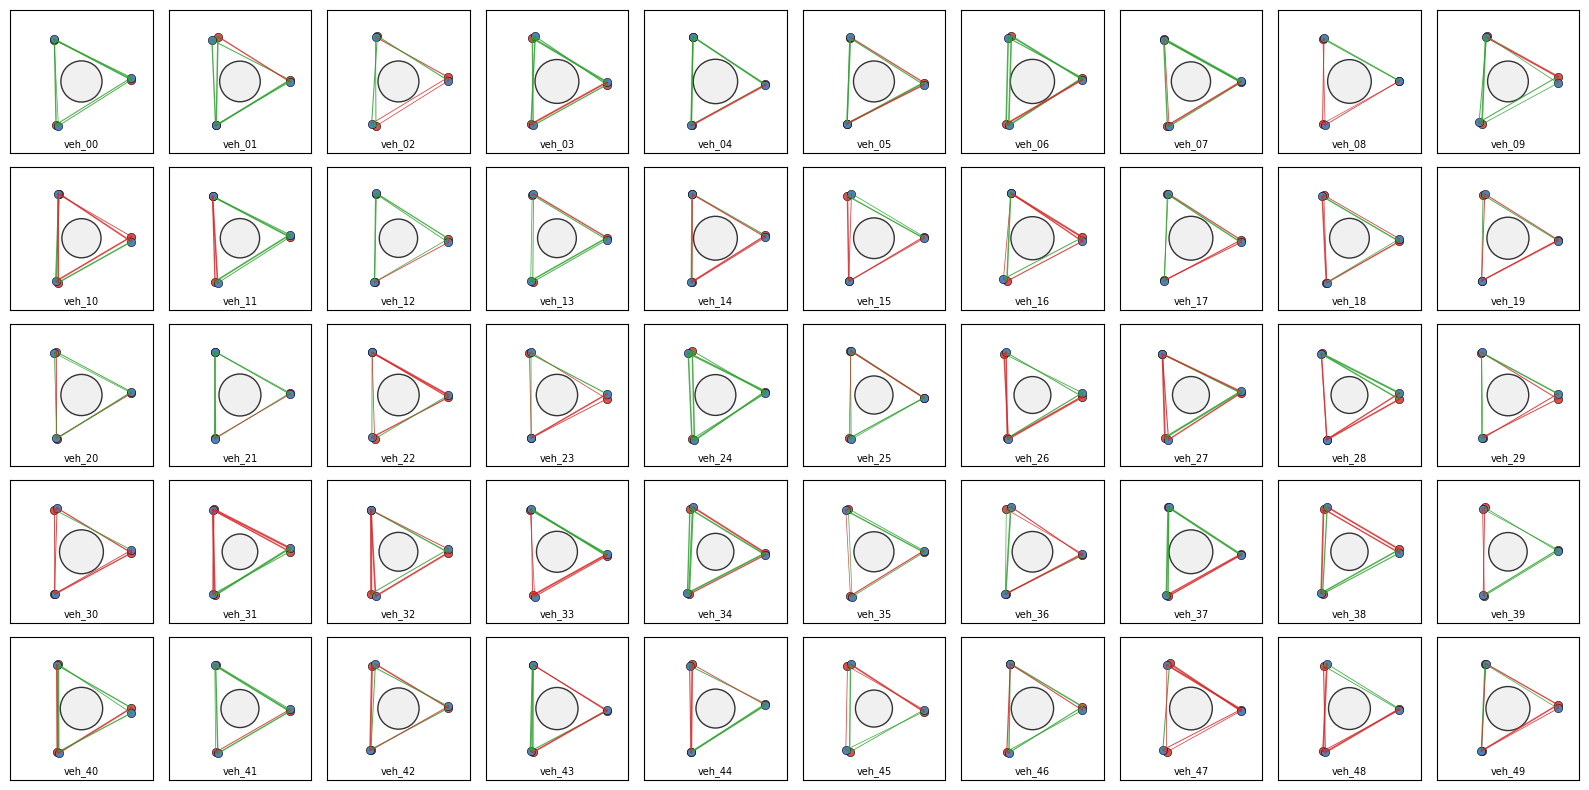

In [ ]:
"""
Generate 50 Braitenberg-style vehicle morphologies using a reservoir network
and visualize them as thumbnails.

Dependencies: numpy, matplotlib, scipy

Save as: generate_braitenberg_reservoir.py
Run: python generate_braitenberg_reservoir.py
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from math import cos, sin, pi
from scipy.special import expit  # sigmoid

# -----------------------------
# Reservoir (Echo State Network) utilities
# -----------------------------
def make_reservoir(n_res=200, spectral_radius=0.9, sparsity=0.1, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(0, 1.0, size=(n_res, n_res))
    mask = rng.random(size=W.shape) < sparsity
    W *= mask
    # scale to spectral radius
    eigs = np.linalg.eigvals(W)
    max_eig = max(abs(eigs)) if len(eigs) > 0 else 1.0
    if max_eig > 0:
        W *= (spectral_radius / max_eig)
    Win = rng.normal(0, 1.0, size=(n_res, 8))  # input dim 8 (random control)
    return W, Win

def run_reservoir(W, Win, inputs, leak=0.3):
    n_res = W.shape[0]
    x = np.zeros(n_res)
    states = []
    for u in inputs:
        pre = W.dot(x) + Win.dot(u)
        x = (1 - leak) * x + leak * np.tanh(pre)
        states.append(x.copy())
    return np.stack(states, axis=0)  # (T, n_res)

# -----------------------------
# Map reservoir state -> morphology parameters
# -----------------------------
def map_state_to_morph(state, rng=None):
    """
    Map a reservoir state vector to a Braitenberg vehicle morphology.
    Returns a dict with:
      - n_sensors (1..4)
      - n_motors (1..4)
      - sensor_positions: list of (x,y) on unit circle
      - motor_positions: list of (x,y) on unit circle
      - wiring: matrix shape (n_sensors, n_motors) of weights (positive excitatory, negative inhibitory)
      - body_radius: float
    """
    if rng is None:
        rng = np.random.default_rng(int(abs(state.sum()*1e6) % (2**31-1)))
    # compress state to a small vector via simple projections
    proj = np.tanh(state[:32])  # take first 32 dims
    # counts
    n_sensors = int(1 + np.clip(int(1 + (expit(proj[0]) * 3)), 0, 4))
    n_motors = int(1 + np.clip(int(1 + (expit(proj[1]) * 3)), 0, 4))
    # body radius
    body_radius = 0.08 + 0.12 * expit(proj[2])
    # positions around circle with jitter
    def positions(k, offset_seed):
        base_angles = np.linspace(0, 2*pi, k, endpoint=False)
        angles = []
        for i, a in enumerate(base_angles):
            jitter = (expit(proj[(3 + offset_seed + i) % len(proj)]) - 0.5) * 0.6
            angles.append(a + jitter)
        pts = [(0.5 + 0.35 * cos(a), 0.5 + 0.35 * sin(a)) for a in angles]
        return pts
    sensor_positions = positions(n_sensors, 0)
    motor_positions = positions(n_motors, 8)
    # wiring weights: use remaining proj entries to create weights
    wiring = np.zeros((n_sensors, n_motors))
    idx = 12
    for i in range(n_sensors):
        for j in range(n_motors):
            val = proj[idx % len(proj)]
            # map to [-1.5, 1.5]
            w = (expit(val) - 0.5) * 3.0
            wiring[i, j] = w
            idx += 1
    # add small random perturbation
    wiring += (rng.normal(scale=0.05, size=wiring.shape))
    return {
        "n_sensors": n_sensors,
        "n_motors": n_motors,
        "sensor_positions": sensor_positions,
        "motor_positions": motor_positions,
        "wiring": wiring,
        "body_radius": body_radius
    }

# -----------------------------
# Visualization utilities
# -----------------------------
def draw_vehicle(ax, morph, title=None):
    # body
    cx, cy = 0.5, 0.5
    r = morph["body_radius"]
    body = Circle((cx, cy), r, facecolor="#f0f0f0", edgecolor="#333333", linewidth=1.0)
    ax.add_patch(body)
    # sensors (red)
    for (sx, sy) in morph["sensor_positions"]:
        ax.plot(sx, sy, 'o', color="#d9534f", markersize=6, markeredgecolor='k', markeredgewidth=0.4)
    # motors (blue)
    for (mx, my) in morph["motor_positions"]:
        ax.plot(mx, my, 'o', color="#4f81bd", markersize=6, markeredgecolor='k', markeredgewidth=0.4)
    # wiring lines
    n_s, n_m = morph["wiring"].shape
    for i in range(n_s):
        sx, sy = morph["sensor_positions"][i]
        for j in range(n_m):
            mx, my = morph["motor_positions"][j]
            w = morph["wiring"][i, j]
            # line color: red for inhibitory (negative), green for excitatory (positive)
            if w >= 0:
                color = "#2ca02c"
            else:
                color = "#d62728"
            lw = 0.5 + 3.0 * (min(1.0, abs(w) / 1.5))
            ax.plot([sx, mx], [sy, my], color=color, linewidth=lw, alpha=0.85)
    # optional title
    if title:
        ax.text(0.5, 0.02, title, ha='center', va='bottom', fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# -----------------------------
# Main generation loop
# -----------------------------
def generate_vehicles(n_vehicles=50, seed=1234):
    rng = np.random.default_rng(seed)
    W, Win = make_reservoir(n_res=300, spectral_radius=0.95, sparsity=0.08, seed=seed)
    # create random input sequences per vehicle (short bursts)
    vehicles = []
    for k in range(n_vehicles):
        # create a short random input sequence (T steps)
        T = 20
        inputs = rng.normal(size=(T, Win.shape[1]))
        states = run_reservoir(W, Win, inputs, leak=0.25)
        # take the last state as the latent descriptor
        last_state = states[-1]
        morph = map_state_to_morph(last_state, rng=rng)
        morph["id"] = f"veh_{k:02d}"
        vehicles.append(morph)
    return vehicles

# -----------------------------
# Plot grid of vehicles
# -----------------------------
def plot_vehicle_grid(vehicles, cols=10, figsize=(14, 7), save_path=None):
    n = len(vehicles)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i in range(rows * cols):
        ax = axes[i]
        if i < n:
            draw_vehicle(ax, vehicles[i], title=vehicles[i]["id"])
        else:
            ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Run and visualize
# -----------------------------
if __name__ == "__main__":
    vehicles = generate_vehicles(n_vehicles=50, seed=2026)
    plot_vehicle_grid(vehicles, cols=10, figsize=(16, 8), save_path="braitenberg_reservoir_50.png")

Generating reservoir latents...
Decoding originals for visualization...
Training denoiser (this may take a minute)...
Epoch 100/400, loss=7.6515e-01
Epoch 200/400, loss=6.5895e-01
Epoch 300/400, loss=6.1041e-01
Epoch 400/400, loss=5.7415e-01
Sampling from reverse diffusion...
Plotting originals vs generated...


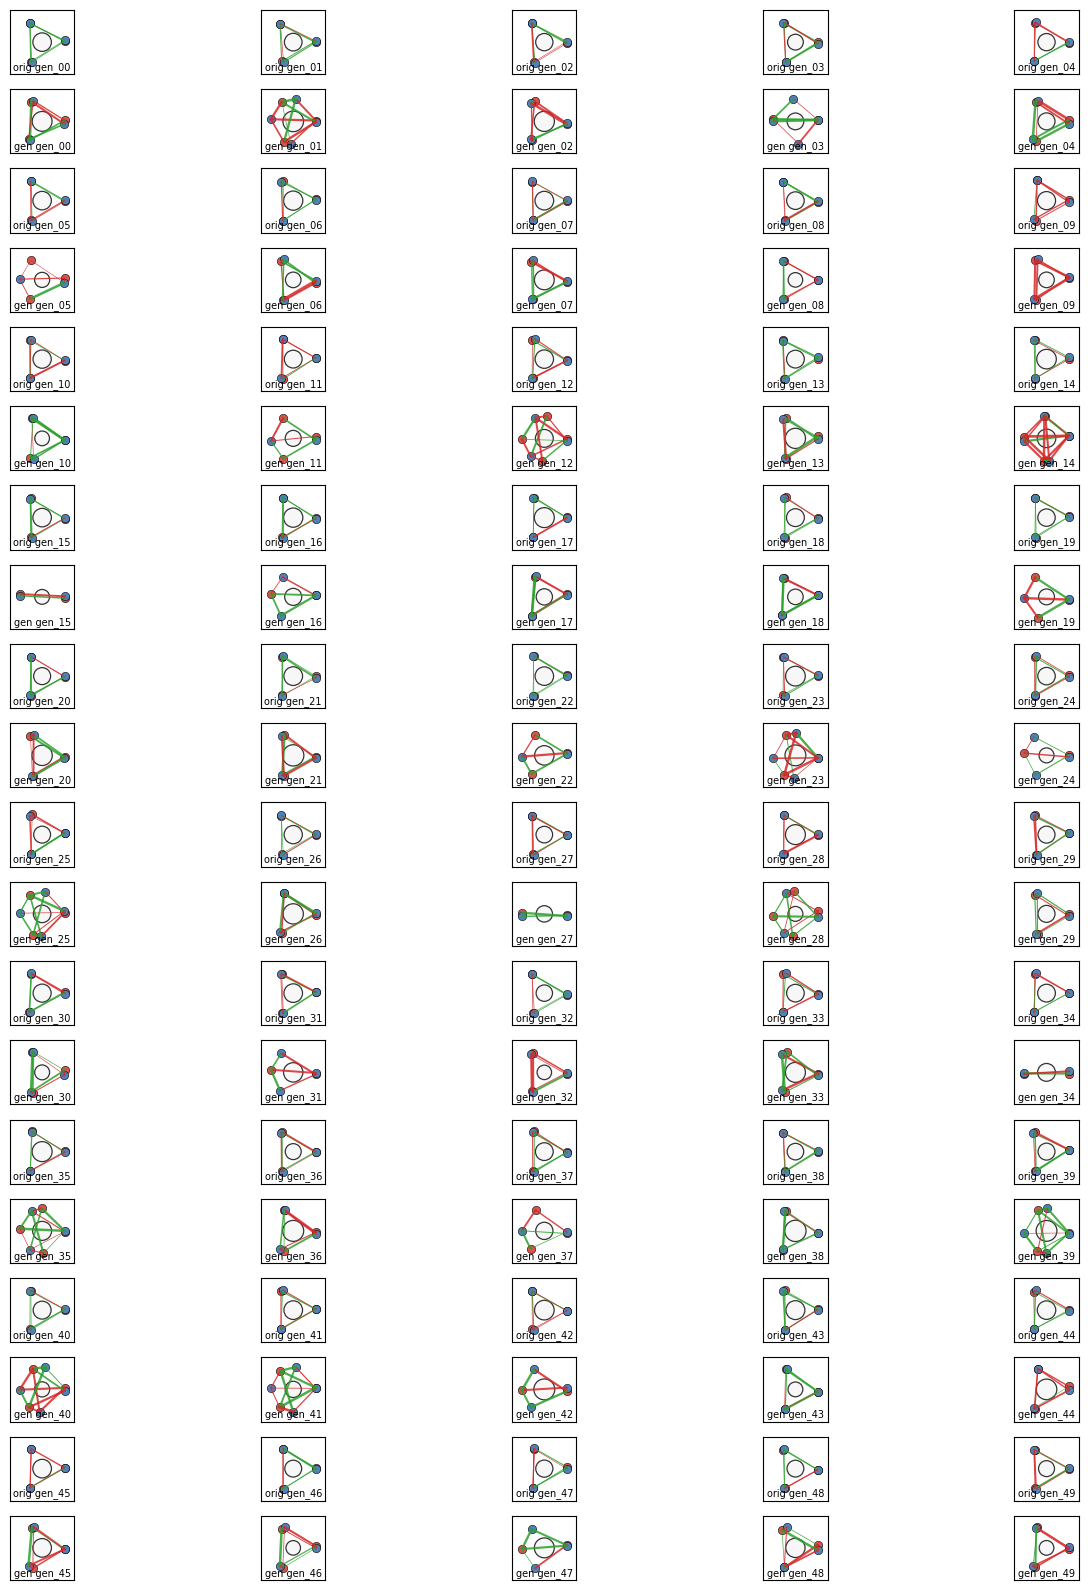

Done. Saved comparison image to braitenberg_diffusion_comparison.png


In [ ]:
"""
Braitenberg morphologies via forward + reverse diffusion in latent space.

Run: python braitenberg_diffusion.py

Dependencies:
  numpy, matplotlib, torch, scipy

What it does:
  - Create 50 reservoir-derived latent vectors
  - Map latents -> morphology parameters (sensors, motors, wiring)
  - Forward diffusion: add Gaussian noise across T timesteps
  - Train a small denoiser to predict noise (simple DDPM-style objective)
  - Reverse sampling from pure noise to produce new latents
  - Decode and plot originals vs generated morphologies
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.special import expit
from scipy.spatial.distance import cdist

# -----------------------------
# Reservoir utilities (same idea as earlier)
# -----------------------------
def make_reservoir(n_res=300, spectral_radius=0.95, sparsity=0.08, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(0, 1.0, size=(n_res, n_res))
    mask = rng.random(size=W.shape) < sparsity
    W *= mask
    # scale to spectral radius
    eigs = np.linalg.eigvals(W)
    max_eig = max(abs(eigs)) if len(eigs) > 0 else 1.0
    if max_eig > 0:
        W *= (spectral_radius / max_eig)
    Win = rng.normal(0, 1.0, size=(n_res, 8))
    return W.astype(np.float32), Win.astype(np.float32)

def run_reservoir(W, Win, inputs, leak=0.3):
    n_res = W.shape[0]
    x = np.zeros(n_res, dtype=np.float32)
    states = []
    for u in inputs:
        pre = W.dot(x) + Win.dot(u)
        x = (1 - leak) * x + leak * np.tanh(pre)
        states.append(x.copy())
    return np.stack(states, axis=0)

# -----------------------------
# Map latent -> morphology
# -----------------------------
def map_state_to_morph(state, rng=None):
    if rng is None:
        rng = np.random.default_rng(int(abs(state.sum()*1e6) % (2**31-1)))
    proj = np.tanh(state[:64])
    # counts
    n_sensors = int(1 + np.clip(int(1 + (expit(proj[0]) * 3)), 0, 4))
    n_motors = int(1 + np.clip(int(1 + (expit(proj[1]) * 3)), 0, 4))
    body_radius = 0.08 + 0.12 * expit(proj[2])
    def positions(k, offset_seed):
        if k == 0:
            return []
        base_angles = np.linspace(0, 2*np.pi, k, endpoint=False)
        angles = []
        for i, a in enumerate(base_angles):
            jitter = (expit(proj[(3 + offset_seed + i) % len(proj)]) - 0.5) * 0.6
            angles.append(a + jitter)
        pts = [(0.5 + 0.35 * np.cos(a), 0.5 + 0.35 * np.sin(a)) for a in angles]
        return pts
    sensor_positions = positions(n_sensors, 0)
    motor_positions = positions(n_motors, 8)
    wiring = np.zeros((n_sensors, n_motors), dtype=np.float32)
    idx = 12
    for i in range(n_sensors):
        for j in range(n_motors):
            val = proj[idx % len(proj)]
            w = (expit(val) - 0.5) * 3.0
            wiring[i, j] = w
            idx += 1
    wiring += rng.normal(scale=0.05, size=wiring.shape)
    return {
        "n_sensors": n_sensors,
        "n_motors": n_motors,
        "sensor_positions": sensor_positions,
        "motor_positions": motor_positions,
        "wiring": wiring,
        "body_radius": body_radius
    }

# -----------------------------
# Drawing helper
# -----------------------------
def draw_vehicle(ax, morph, title=None):
    cx, cy = 0.5, 0.5
    r = morph["body_radius"]
    body = Circle((cx, cy), r, facecolor="#f7f7f7", edgecolor="#333333", linewidth=0.9)
    ax.add_patch(body)
    for (sx, sy) in morph["sensor_positions"]:
        ax.plot(sx, sy, 'o', color="#d9534f", markersize=6, markeredgecolor='k', markeredgewidth=0.4)
    for (mx, my) in morph["motor_positions"]:
        ax.plot(mx, my, 'o', color="#4f81bd", markersize=6, markeredgecolor='k', markeredgewidth=0.4)
    n_s, n_m = morph["wiring"].shape
    for i in range(n_s):
        sx, sy = morph["sensor_positions"][i]
        for j in range(n_m):
            mx, my = morph["motor_positions"][j]
            w = morph["wiring"][i, j]
            color = "#2ca02c" if w >= 0 else "#d62728"
            lw = 0.4 + 3.0 * (min(1.0, abs(w) / 1.5))
            ax.plot([sx, mx], [sy, my], color=color, linewidth=lw, alpha=0.85)
    if title:
        ax.text(0.5, 0.02, title, ha='center', va='bottom', fontsize=7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

# -----------------------------
# Diffusion utilities (DDPM-style in latent space)
# -----------------------------
def make_noise_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = np.linspace(beta_start, beta_end, T, dtype=np.float32)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas, axis=0)
    return betas, alphas, alpha_bars

class Denoiser(nn.Module):
    def __init__(self, latent_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, latent_dim),
        )
    def forward(self, x, t):
        # x: (B, D), t: (B,) normalized to [0,1]
        t = t.unsqueeze(1)
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

# -----------------------------
# Generate reservoir latents (original dataset)
# -----------------------------
def generate_reservoir_latents(n=50, latent_dim=300, seed=2026):
    rng = np.random.default_rng(seed)
    W, Win = make_reservoir(n_res=latent_dim, spectral_radius=0.95, sparsity=0.08, seed=seed)
    latents = []
    for k in range(n):
        T = 20
        inputs = rng.normal(size=(T, Win.shape[1])).astype(np.float32)
        states = run_reservoir(W, Win, inputs, leak=0.25)
        last_state = states[-1]
        latents.append(last_state.astype(np.float32))
    return np.stack(latents, axis=0)  # (n, latent_dim)

# -----------------------------
# Training denoiser on synthetic pairs
# -----------------------------
def train_denoiser(denoiser, latents, betas, alpha_bars, epochs=400, batch_size=16, lr=1e-3, device='cpu'):
    denoiser.to(device)
    opt = optim.Adam(denoiser.parameters(), lr=lr)
    n, D = latents.shape
    lat_torch = torch.tensor(latents, device=device)
    T = len(betas)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            x0 = lat_torch[idx]  # (B, D)
            B = x0.size(0)
            t_idx = torch.randint(0, T, (B,), device=device)
            alpha_bar_t = torch.tensor(alpha_bars[t_idx.cpu().numpy()], device=device).unsqueeze(1)
            noise = torch.randn_like(x0)
            xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * noise
            t_norm = t_idx.float() / float(T - 1)
            pred_noise = denoiser(xt, t_norm)
            loss = ((pred_noise - noise) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        # optional small print
        if (ep + 1) % 100 == 0:
            print(f"Epoch {ep+1}/{epochs}, loss={loss.item():.4e}")
    return denoiser

# -----------------------------
# Reverse sampling (DDPM simple)
# -----------------------------
def reverse_sample(denoiser, n_samples, latent_dim, betas, alphas, alpha_bars, device='cpu'):
    T = len(betas)
    denoiser.to(device)
    x = torch.randn(n_samples, latent_dim, device=device)
    for t in reversed(range(T)):
        t_idx = torch.full((n_samples,), t, device=device, dtype=torch.long)
        t_norm = t_idx.float() / float(T - 1)
        with torch.no_grad():
            pred_noise = denoiser(x, t_norm)
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        if t == 0:
            coef1 = 1.0 / np.sqrt(alpha_t)
            coef2 = (beta_t / np.sqrt(1.0 - alpha_bar_t))
            x = coef1 * (x - coef2 * pred_noise)
        else:
            coef1 = 1.0 / np.sqrt(alpha_t)
            coef2 = (beta_t / np.sqrt(1.0 - alpha_bar_t))
            mean = coef1 * (x - coef2 * pred_noise)
            noise = torch.randn_like(x)
            sigma = np.sqrt(beta_t)
            x = mean + sigma * noise
    return x.cpu().numpy()

# -----------------------------
# Decode latents to morphologies
# -----------------------------
def decode_latents_to_morphs(latents):
    morphs = []
    for i, z in enumerate(latents):
        morph = map_state_to_morph(z, rng=np.random.default_rng(i+123))
        morph["id"] = f"gen_{i:02d}"
        morphs.append(morph)
    return morphs

# -----------------------------
# Plot grid comparing originals and generated
# -----------------------------
def plot_comparison_grid(orig_morphs, gen_morphs, cols=5, figsize=(14, 12), save_path=None):
    n = len(orig_morphs)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows*2, cols, figsize=figsize)
    axes = axes.reshape(rows*2, cols)
    for i in range(rows*cols):
        r = i // cols
        c = i % cols
        ax_orig = axes[2*r, c]
        ax_gen = axes[2*r+1, c]
        if i < n:
            draw_vehicle(ax_orig, orig_morphs[i], title=f"orig {orig_morphs[i]['id']}")
            draw_vehicle(ax_gen, gen_morphs[i], title=f"gen {gen_morphs[i]['id']}")
        else:
            ax_orig.axis('off'); ax_gen.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Main pipeline
# -----------------------------
def main():
    device = 'cpu'  # change to 'cuda' if available
    n = 50
    latent_dim = 300
    print("Generating reservoir latents...")
    latents = generate_reservoir_latents(n=n, latent_dim=latent_dim, seed=2026)
    print("Decoding originals for visualization...")
    orig_morphs = decode_latents_to_morphs(latents)

    # diffusion schedule
    T = 50
    betas, alphas, alpha_bars = make_noise_schedule(T, beta_start=1e-4, beta_end=0.02)

    # instantiate denoiser
    denoiser = Denoiser(latent_dim=latent_dim, hidden=512)

    # train denoiser on the dataset (we use the same latents as training data)
    print("Training denoiser (this may take a minute)...")
    denoiser = train_denoiser(denoiser, latents, betas, alpha_bars, epochs=400, batch_size=16, lr=1e-3, device=device)

    # reverse sample
    print("Sampling from reverse diffusion...")
    gen_latents = reverse_sample(denoiser, n_samples=n, latent_dim=latent_dim,
                                 betas=betas, alphas=alphas, alpha_bars=alpha_bars, device=device)

    gen_morphs = decode_latents_to_morphs(gen_latents)

    # plot comparison
    print("Plotting originals vs generated...")
    plot_comparison_grid(orig_morphs, gen_morphs, cols=5, figsize=(14, 16), save_path="braitenberg_diffusion_comparison.png")
    print("Done. Saved comparison image to braitenberg_diffusion_comparison.png")

if __name__ == "__main__":
    main()

Generating reservoir latents and applying forward diffusion...
Decoding originals and noised latents to morphologies...
Plotting originals vs forward-diffused morphologies...


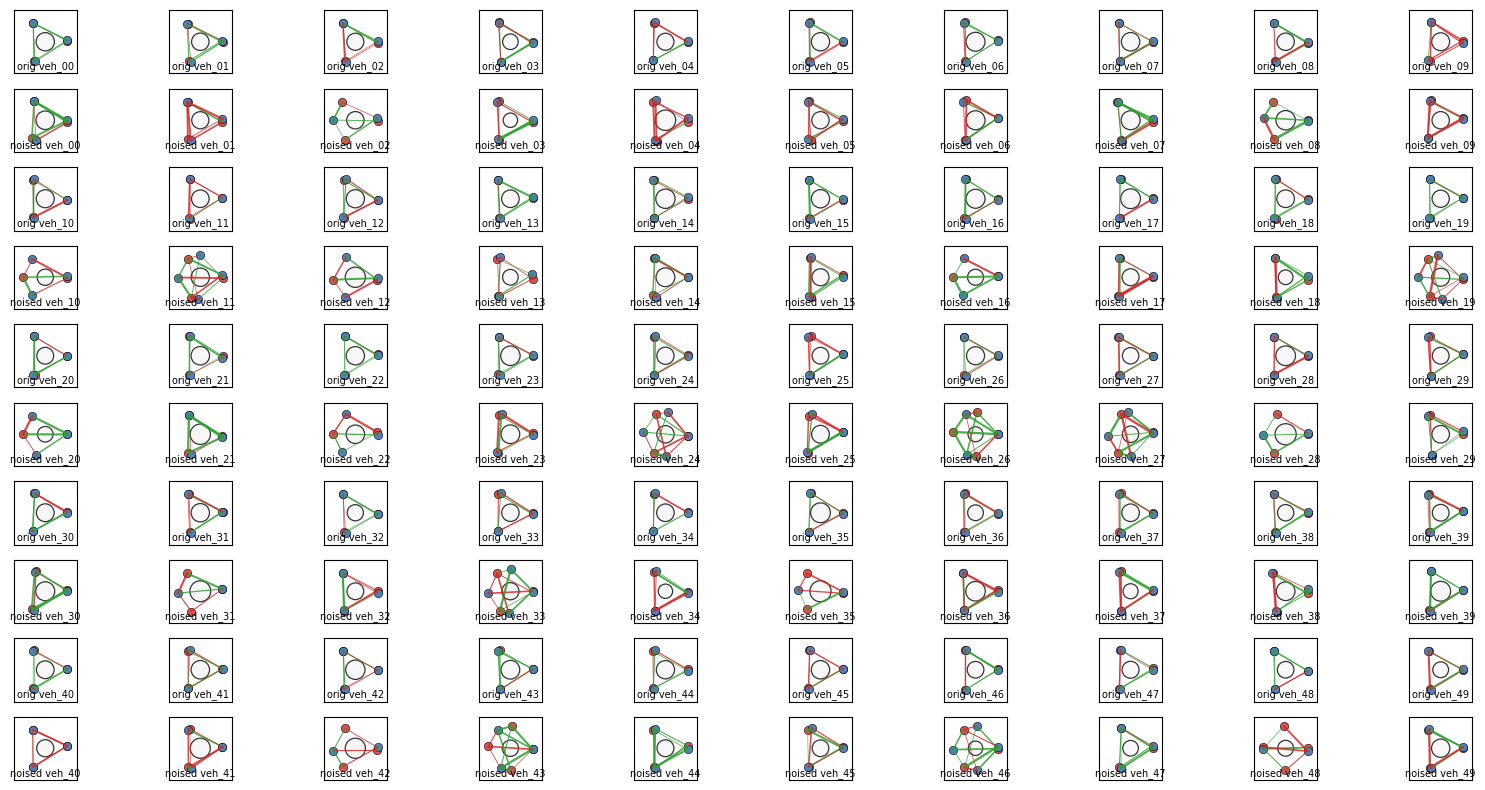

Done.


In [ ]:
"""
braitenberg_forward_diffusion.py

Generate 50 Braitenberg-style morphologies from reservoir latents,
apply a forward diffusion (Gaussian noise schedule) in latent space,
decode noisy latents to morphologies, and visualize originals vs noised versions.

Dependencies: numpy, matplotlib, torch, scipy
Run: python braitenberg_forward_diffusion.py
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
from scipy.special import expit
import torch

# -----------------------------
# Reservoir utilities (simple ESN)
# -----------------------------
def make_reservoir(n_res=300, spectral_radius=0.95, sparsity=0.08, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(0, 1.0, size=(n_res, n_res))
    mask = rng.random(size=W.shape) < sparsity
    W *= mask
    # scale to spectral radius
    eigs = np.linalg.eigvals(W)
    max_eig = max(abs(eigs)) if len(eigs) > 0 else 1.0
    if max_eig > 0:
        W *= (spectral_radius / max_eig)
    Win = rng.normal(0, 1.0, size=(n_res, 8))
    return W.astype(np.float32), Win.astype(np.float32)

def run_reservoir(W, Win, inputs, leak=0.3):
    n_res = W.shape[0]
    x = np.zeros(n_res, dtype=np.float32)
    for u in inputs:
        pre = W.dot(x) + Win.dot(u)
        x = (1 - leak) * x + leak * np.tanh(pre)
    return x  # return final state

# -----------------------------
# Map latent -> morphology (deterministic)
# -----------------------------
def map_state_to_morph(state, rng=None):
    if rng is None:
        rng = np.random.default_rng(int(abs(state.sum()*1e6) % (2**31-1)))
    proj = np.tanh(state[:64])
    # counts
    n_sensors = int(1 + np.clip(int(1 + (expit(proj[0]) * 3)), 0, 4))
    n_motors = int(1 + np.clip(int(1 + (expit(proj[1]) * 3)), 0, 4))
    body_radius = 0.08 + 0.12 * expit(proj[2])
    def positions(k, offset_seed):
        if k == 0:
            return []
        base_angles = np.linspace(0, 2*np.pi, k, endpoint=False)
        angles = []
        for i, a in enumerate(base_angles):
            jitter = (expit(proj[(3 + offset_seed + i) % len(proj)]) - 0.5) * 0.6
            angles.append(a + jitter)
        pts = [(0.5 + 0.35 * np.cos(a), 0.5 + 0.35 * np.sin(a)) for a in angles]
        return pts
    sensor_positions = positions(n_sensors, 0)
    motor_positions = positions(n_motors, 8)
    wiring = np.zeros((n_sensors, n_motors), dtype=np.float32)
    idx = 12
    for i in range(n_sensors):
        for j in range(n_motors):
            val = proj[idx % len(proj)]
            w = (expit(val) - 0.5) * 3.0
            wiring[i, j] = w
            idx += 1
    wiring += rng.normal(scale=0.05, size=wiring.shape)
    return {
        "n_sensors": n_sensors,
        "n_motors": n_motors,
        "sensor_positions": sensor_positions,
        "motor_positions": motor_positions,
        "wiring": wiring,
        "body_radius": body_radius
    }

# -----------------------------
# Drawing helper
# -----------------------------
def draw_vehicle(ax, morph, title=None):
    cx, cy = 0.5, 0.5
    r = morph["body_radius"]
    body = Circle((cx, cy), r, facecolor="#f7f7f7", edgecolor="#333333", linewidth=0.9)
    ax.add_patch(body)
    for (sx, sy) in morph["sensor_positions"]:
        ax.plot(sx, sy, 'o', color="#d9534f", markersize=6, markeredgecolor='k', markeredgewidth=0.4)
    for (mx, my) in morph["motor_positions"]:
        ax.plot(mx, my, 'o', color="#4f81bd", markersize=6, markeredgecolor='k', markeredgewidth=0.4)
    n_s, n_m = morph["wiring"].shape
    for i in range(n_s):
        sx, sy = morph["sensor_positions"][i]
        for j in range(n_m):
            mx, my = morph["motor_positions"][j]
            w = morph["wiring"][i, j]
            color = "#2ca02c" if w >= 0 else "#d62728"
            lw = 0.4 + 3.0 * (min(1.0, abs(w) / 1.5))
            ax.plot([sx, mx], [sy, my], color=color, linewidth=lw, alpha=0.85)
    if title:
        ax.text(0.5, 0.02, title, ha='center', va='bottom', fontsize=7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

# -----------------------------
# Forward diffusion schedule (DDPM-style forward only)
# -----------------------------
def make_noise_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = np.linspace(beta_start, beta_end, T, dtype=np.float32)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas, axis=0)
    return betas, alphas, alpha_bars

def forward_diffuse(x0, t_idx, alpha_bars, rng=None):
    """
    Produce x_t from x0 using closed-form:
      x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise
    t_idx: integer timestep (0..T-1)
    """
    if rng is None:
        rng = np.random.default_rng()
    alpha_bar_t = alpha_bars[t_idx]
    noise = rng.normal(size=x0.shape).astype(np.float32)
    xt = np.sqrt(alpha_bar_t) * x0 + np.sqrt(1.0 - alpha_bar_t) * noise
    return xt

# -----------------------------
# Generate reservoir latents and apply forward diffusion
# -----------------------------
def generate_and_diffuse(n=50, latent_dim=300, seed=2026, T=50, t_observe=None):
    rng = np.random.default_rng(seed)
    W, Win = make_reservoir(n_res=latent_dim, spectral_radius=0.95, sparsity=0.08, seed=seed)
    latents = []
    for k in range(n):
        inputs = rng.normal(size=(20, Win.shape[1])).astype(np.float32)
        z = run_reservoir(W, Win, inputs, leak=0.25)
        latents.append(z.astype(np.float32))
    latents = np.stack(latents, axis=0)  # (n, D)

    betas, alphas, alpha_bars = make_noise_schedule(T)
    if t_observe is None:
        t_observe = T - 1  # show the final noisy step by default

    noised_latents = np.stack([forward_diffuse(latents[i], t_observe, alpha_bars, rng=rng) for i in range(n)], axis=0)
    return latents, noised_latents, (betas, alphas, alpha_bars)

# -----------------------------
# Decode latents to morphologies
# -----------------------------
def decode_latents_to_morphs(latents):
    morphs = []
    for i, z in enumerate(latents):
        morph = map_state_to_morph(z, rng=np.random.default_rng(i+123))
        morph["id"] = f"veh_{i:02d}"
        morphs.append(morph)
    return morphs

# -----------------------------
# Plot grid originals vs forward-diffused
# -----------------------------
def plot_orig_vs_noised(orig_morphs, noised_morphs, cols=10, figsize=(16, 8), save_path=None):
    n = len(orig_morphs)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(2*rows, cols, figsize=figsize)
    axes = axes.reshape(2*rows, cols)
    for i in range(rows*cols):
        r = i // cols
        c = i % cols
        ax_orig = axes[2*r, c]
        ax_noised = axes[2*r+1, c]
        if i < n:
            draw_vehicle(ax_orig, orig_morphs[i], title=f"orig {orig_morphs[i]['id']}")
            draw_vehicle(ax_noised, noised_morphs[i], title=f"noised {noised_morphs[i]['id']}")
        else:
            ax_orig.axis('off'); ax_noised.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    n = 50
    latent_dim = 300
    T = 50
    # choose which forward timestep to visualize (0..T-1). 0 = almost original, T-1 = most noisy.
    t_observe = T - 1

    print("Generating reservoir latents and applying forward diffusion...")
    latents, noised_latents, schedule = generate_and_diffuse(n=n, latent_dim=latent_dim, seed=2026, T=T, t_observe=t_observe)

    print("Decoding originals and noised latents to morphologies...")
    orig_morphs = decode_latents_to_morphs(latents)
    noised_morphs = decode_latents_to_morphs(noised_latents)

    print("Plotting originals vs forward-diffused morphologies...")
    plot_orig_vs_noised(orig_morphs, noised_morphs, cols=10, figsize=(16, 8))
    print("Done.")